In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

## 1 — Load & Parse Data: ClassTran Ecolane reservation and trip data

This notebook uses the Ecolane reservation/trip workbook for July 2022 through June 2023. The workbook sheet is `SMART Trip Data`. After loading, the code creates standardized address and coordinate aliases such as `pickup_address`, `dropoff_address`, `pickup_lat`, `pickup_lon`, `dropoff_lat`, and `dropoff_lon` so the downstream analysis can use the same field names throughout the notebook.


In [2]:
from pathlib import Path


DATA_PATH = Path(
    "/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/"
    "Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx"
)
SHEET_NAME = "SMART Trip Data"
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)


def combine_address_parts(df, street_number_col, street_col, city_col, state_col, zipcode_col):
    parts = []
    for col in [street_number_col, street_col, city_col, state_col, zipcode_col]:
        part = df[col].fillna('').astype(str).str.strip()
        part = part.str.replace(r'\.0$', '', regex=True)
        parts.append(part)
    address = parts[0] + ' ' + parts[1]
    address = address.str.strip()
    city_state_zip = parts[2] + ', ' + parts[3] + ' ' + parts[4]
    city_state_zip = city_state_zip.str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)
    return (address + ', ' + city_state_zip).str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)


# Standardize Ecolane column names used by later cells.
df_raw['pickup_lat'] = df_raw['Pick-up Latitude']
df_raw['pickup_lon'] = df_raw['Pick-up Longitude']
df_raw['dropoff_lat'] = df_raw['Drop-off Latitude']
df_raw['dropoff_lon'] = df_raw['Drop-off Longitude']
df_raw['pickup_address'] = combine_address_parts(
    df_raw,
    'Pick-up Street Number', 'Pick-up Street', 'Pick-up City', 'Pick-up State', 'Pick-up Zipcode',
)
df_raw['dropoff_address'] = combine_address_parts(
    df_raw,
    'Drop-off Street Number', 'Drop-off Street', 'Drop-off City', 'Drop-off State', 'Drop-off Zipcode',
)

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(['comp', 'completed']).sum()
cancelled_trips = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
noshow_trips = status_clean.isin(['noshow', 'no show', 'no-show']).sum()

print(f"Source workbook: {DATA_PATH.name}")
print(f"Sheet: {SHEET_NAME}")
print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
print(f"Columns:  {list(df_raw.columns)}")
df_raw.head(3)


Source workbook: Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx
Sheet: SMART Trip Data
Total trips: 121,281
Completed trips: 63,841
Cancelled trips: 54,121
No-show trips: 3,319
Unique customers: 1,052
Purpose types (10): ['Dialysis', 'Education', 'Employment', 'Medical', 'Nutrition', 'Personal', 'Recreation', 'Shopping', 'Trolley', 'Workshop']
Trip date range: 2022-07-01 to 2023-06-30
Columns:  ['Customer Number', 'Client Age', 'Edit Agent', 'Edit Timestamp', 'Trip ID', 'Trip Date', 'Trip Status', 'Mobility Device', 'Subscription Number', 'Reservation Agent', 'Order Time', 'Other Passengers', 'PCA', 'Companions', 'Children', 'Total Passengers', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'No Show Reason', 'Cluster ID', 'Pick-up OTP (minutes)', 'Vehicle Requirement', 'Direct Estimated Distance', 'Wheelchair Count', 'Direct Estimated Duration', 'Promised Pick-up Time', 'Promised Drop-off Time', 'Earliest Pick-up', 'Latest Pick-up Time', 'Earliest Drop-off Time', 'Latest D

,Customer Number,Client Age,Edit Agent,Edit Timestamp,Trip ID,Trip Date,Trip Status,Mobility Device,Subscription Number,Reservation Agent,...,Run ID,Vehicle Company,Vehicle ID,Transportation Provider,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_address,dropoff_address
0,23083,55.0,NaN,NaT,286854,2022-07-01,cancel,cane,4152.0,sub,...,NaN,NaN,NaN,ClasTran,33.543593,-86.572576,33.531577,-86.715948,"407 Forest Way, Leeds, AL 35094","7780 Ludington Ln, Irondale, AL 35210"
1,14909,60.0,cmcneal,2022-07-06 09:45:55,286738,2022-07-01,comp,cane,2599.0,sub,...,E&I-102,Ebony & Ivory,3799,Ebony & Ivory,33.603306,-86.711765,33.475050,-86.823489,"308 Glynn Dr, Birmingham, Al 35215","529 Beacon Pkwy W, Birmingham, AL 35209"
2,6712,75.0,NaN,NaT,286886,2022-07-01,comp,none,4221.0,sub,...,Finch,ClasTran,1520,ClasTran,33.546257,-86.558513,33.531577,-86.715948,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210"


# Here, we discuss the completion rate for each purpose, and we also summarize the cancellation types. 

In [10]:
purpose_completion_rate = (
    df_raw.assign(status_clean=status_clean)
    .dropna(subset=['Purpose'])
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
)

purpose_completion_rate['completed_rate'] = (
    purpose_completion_rate['completed_trips'] / purpose_completion_rate['total_trips']
)
purpose_completion_rate = purpose_completion_rate.sort_values('completed_rate', ascending=False)

display(purpose_completion_rate.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

cancel_statuses = ['cancel', 'canceled', 'cancelled']
cancelled_mask = status_clean.isin(cancel_statuses)
df_cancelled = df_raw.loc[cancelled_mask].copy()
df_cancelled['cancel_type_clean'] = (
    df_cancelled['Cancel Type']
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

total_cancellations = int(cancelled_mask.sum())
cancel_type_summary = (
    df_cancelled
    .groupby('cancel_type_clean')
    .agg(num_cancellations=('Trip ID', 'count'))
    .sort_values('num_cancellations', ascending=False)
)
cancel_type_summary['share_of_cancellations'] = (
    cancel_type_summary['num_cancellations'] / total_cancellations
)

print(f"Total cancellations: {total_cancellations:,}")
print(f"Cancellation types: {cancel_type_summary.shape[0]:,}")
display(cancel_type_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'share_of_cancellations': '{:.2%}',
}))


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
Trolley,12,12,0,0,100.00%
Dialysis,"13,186","7,851","5,078",257,59.54%
Workshop,"5,511","3,204","2,245",62,58.14%
Education,"1,526",878,634,14,57.54%
Employment,"13,619","7,818","5,582",219,57.41%
Nutrition,"64,285","36,847","25,229","2,209",57.32%
Recreation,"1,001",409,554,38,40.86%
Shopping,"2,192",668,"1,492",32,30.47%
Medical,"17,015","5,169","11,404",442,30.38%


Total cancellations: 54,121
Cancellation types: 16


,num_cancellations,share_of_cancellations
cancel_type_clean,,
Advanced Cancel,"16,075",29.70%
Trip correction,"16,017",29.59%
Modified,"6,805",12.57%
Renegotiation,"6,650",12.29%
Site closure,"4,310",7.96%
Denial,"2,081",3.85%
Late Cancel,"1,017",1.88%
User Error Cancel,754,1.39%
Policy Cancel,181,0.33%


Assume: More flexible purposes may have higher cancellation/adjustment behavior,
while obligatory trips are more regular and less flexible.

In [9]:
completed_statuses = ['comp', 'completed']
noshow_statuses = ['noshow', 'no show', 'no-show']

purpose_base = df_raw.assign(
    Purpose=(
        df_raw['Purpose']
        .astype('string')
        .str.strip()
        .fillna('Missing / Unknown')
        .replace('', 'Missing / Unknown')
    ),
    status_clean=status_clean,
)

purpose_trip_analysis = (
    purpose_base
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(completed_statuses).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(cancel_statuses).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(noshow_statuses).sum()),
    )
)
purpose_trip_analysis['completed_rate'] = (
    purpose_trip_analysis['completed_trips'] / purpose_trip_analysis['total_trips']
)
purpose_trip_analysis['cancellation_rate'] = (
    purpose_trip_analysis['cancelled_trips'] / purpose_trip_analysis['total_trips']
)
purpose_trip_analysis = purpose_trip_analysis.sort_values(
    ['cancellation_rate', 'total_trips'], ascending=[False, False]
)

purpose_cancelled = df_cancelled.copy()
purpose_cancelled['Purpose'] = (
    purpose_cancelled['Purpose']
    .astype('string')
    .str.strip()
    .fillna('Missing / Unknown')
    .replace('', 'Missing / Unknown')
)

purpose_cancel_reason_summary = (
    purpose_cancelled
    .groupby(['Purpose', 'cancel_type_clean'])
    .agg(num_cancellations=('Trip ID', 'count'))
    .reset_index()
)
purpose_cancel_reason_summary['purpose_total_cancellations'] = (
    purpose_cancel_reason_summary.groupby('Purpose')['num_cancellations'].transform('sum')
)
purpose_cancel_reason_summary['share_within_purpose_cancellations'] = (
    purpose_cancel_reason_summary['num_cancellations']
    / purpose_cancel_reason_summary['purpose_total_cancellations']
)
purpose_cancel_reason_summary = purpose_cancel_reason_summary.sort_values(
    ['Purpose', 'num_cancellations'], ascending=[True, False]
)

# Keep Medical-specific outputs for direct comparison with the original analysis.
medical_completion_summary = purpose_trip_analysis.loc[['Medical']].T.rename(columns={'Medical': 'value'})
medical_cancel_reason_summary = (
    purpose_cancel_reason_summary
    .loc[purpose_cancel_reason_summary['Purpose'].eq('Medical'), [
        'cancel_type_clean', 'num_cancellations', 'share_within_purpose_cancellations'
    ]]
    .set_index('cancel_type_clean')
    .rename(columns={'share_within_purpose_cancellations': 'share_of_medical_cancellations'})
)

print('Trip completion and cancellation overview by purpose:')
display(purpose_trip_analysis.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
    'cancellation_rate': '{:.2%}',
}))

print('Cancellation reasons by purpose:')
display(purpose_cancel_reason_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'purpose_total_cancellations': '{:,.0f}',
    'share_within_purpose_cancellations': '{:.2%}',
}))

top_cancel_reason_by_purpose = (
    purpose_cancel_reason_summary.groupby('Purpose', as_index=False)
    .first()
    .rename(columns={'cancel_type_clean': 'top_cancel_type'})
)
top_cancel_reason_by_purpose = (
    purpose_trip_analysis[['cancelled_trips']]
    .reset_index()
    .merge(top_cancel_reason_by_purpose, on='Purpose', how='left')
)
top_cancel_reason_by_purpose['top_cancel_type'] = (
    top_cancel_reason_by_purpose['top_cancel_type'].fillna('No cancellations')
)
top_cancel_reason_by_purpose['num_cancellations'] = (
    top_cancel_reason_by_purpose['num_cancellations'].fillna(0).astype(int)
)
top_cancel_reason_by_purpose['purpose_total_cancellations'] = (
    top_cancel_reason_by_purpose['purpose_total_cancellations']
    .fillna(top_cancel_reason_by_purpose['cancelled_trips'])
    .astype(int)
)
top_cancel_reason_by_purpose['share_within_purpose_cancellations'] = (
    top_cancel_reason_by_purpose['share_within_purpose_cancellations'].fillna(0.0)
)
top_cancel_reason_by_purpose = top_cancel_reason_by_purpose.drop(columns='cancelled_trips')

print('Top cancellation reason within each purpose:')
display(top_cancel_reason_by_purpose.style.format({
    'num_cancellations': '{:,.0f}',
    'purpose_total_cancellations': '{:,.0f}',
    'share_within_purpose_cancellations': '{:.2%}',
}))

if not medical_cancel_reason_summary.empty:
    top_reason = medical_cancel_reason_summary.index[0]
    top_reason_share = medical_cancel_reason_summary.iloc[0]['share_of_medical_cancellations']
    print(
        f"Medical has a low completion rate partly because cancellations are dominated by {top_reason} "
        f"({top_reason_share:.2%} of medical cancellations)."
    )


Trip completion and cancellation overview by purpose:


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate,cancellation_rate
Purpose,,,,,,
Personal,"2,689",740,"1,903",46,27.52%,70.77%
Shopping,"2,192",668,"1,492",32,30.47%,68.07%
Medical,"17,015","5,169","11,404",442,30.38%,67.02%
Recreation,"1,001",409,554,38,40.86%,55.34%
Education,"1,526",878,634,14,57.54%,41.55%
Employment,"13,619","7,818","5,582",219,57.41%,40.99%
Workshop,"5,511","3,204","2,245",62,58.14%,40.74%
Nutrition,"64,285","36,847","25,229","2,209",57.32%,39.25%
Dialysis,"13,186","7,851","5,078",257,59.54%,38.51%


Cancellation reasons by purpose:


,Purpose,cancel_type_clean,num_cancellations,purpose_total_cancellations,share_within_purpose_cancellations
13,Dialysis,Trip correction,"2,113","5,078",41.61%
7,Dialysis,Modified,"1,216","5,078",23.95%
0,Dialysis,Advanced Cancel,"1,198","5,078",23.59%
2,Dialysis,Denial,186,"5,078",3.66%
11,Dialysis,Renegotiation,134,"5,078",2.64%
14,Dialysis,User Error Cancel,101,"5,078",1.99%
5,Dialysis,Late Cancel,82,"5,078",1.61%
9,Dialysis,Policy Cancel,25,"5,078",0.49%
6,Dialysis,Missing / Unknown,9,"5,078",0.18%
12,Dialysis,Site closure,5,"5,078",0.10%


Top cancellation reason within each purpose:


,Purpose,top_cancel_type,num_cancellations,purpose_total_cancellations,share_within_purpose_cancellations
0,Personal,Trip correction,"1,152","1,903",60.54%
1,Shopping,Trip correction,898,"1,492",60.19%
2,Medical,Trip correction,"6,579","11,404",57.69%
3,Recreation,Trip correction,328,554,59.21%
4,Education,Trip correction,307,634,48.42%
5,Employment,Trip correction,"2,153","5,582",38.57%
6,Workshop,Trip correction,684,"2,245",30.47%
7,Nutrition,Advanced Cancel,"9,922","25,229",39.33%
8,Dialysis,Trip correction,"2,113","5,078",41.61%
9,Missing / Unknown,No cancellations,0,0,0.00%


Medical has a low completion rate partly because cancellations are dominated by Trip correction (57.69% of medical cancellations).


# 2. Filter dataset

In [16]:
keep_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID',
    'Earliest Pick-up', 'Latest Drop-off Time',
    # 'Scheduled Pick-up Departure Time',
    # 'Requested Pick-up Time', 
    'Reported Pick-up Arrival Time', 
    # 'Reported Pick-up Departure Time',
    # 'Requested Drop-off Time', 
    'Reported Drop-Off Arrival Time', 
    # 'Reported Drop-Off Departure Time',
    # 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    # 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Purpose', 'pickup_address', 'dropoff_address',
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
]
# 1. quantify the flexibility index for the rider from the dataset (why we make some assumptions?)

# waiting time for one rider, distribution patterns, purpose, one year, behavior, OD pair, time of day, 

# demand pattern analysis, how possible we can deviate the demand to make the system more efficient?

# how we use this? increase the flexibility 10%, anchor, by changing this value,  
# simulation for the scheduling performance, check utilization,

# simulation, performance better, 
 
# Keep only completed trips with complete required timing, address, purpose, and coordinate fields.
df_clean = df_raw[keep_cols].copy()
df_clean = df_clean[df_clean['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])]
df_clean = df_clean.dropna(subset=keep_cols).copy()

print(f"Completed rows after required-column NaN filtering: {len(df_clean):,}")
df_clean.head(3)


Completed rows after required-column NaN filtering: 63,596


,Customer Number,Trip ID,Trip Date,Trip Status,Run ID,Earliest Pick-up,Latest Drop-off Time,Scheduled Pick-up Arrival Time,Reported Pick-up Arrival Time,Reported Drop-Off Arrival Time,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
1,14909,286738,2022-07-01,comp,E&I-102,05:30:00,06:48:00,2022-07-01 05:45:41,05:26:00,05:49:00,Employment,"308 Glynn Dr, Birmingham, Al 35215","529 Beacon Pkwy W, Birmingham, AL 35209",33.603306,-86.711765,33.475050,-86.823489
2,6712,286886,2022-07-01,comp,Finch,06:00:00,07:03:00,2022-07-01 06:15:00,06:54:00,07:23:00,Dialysis,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210",33.546257,-86.558513,33.531577,-86.715948
3,5801,286851,2022-07-01,comp,Finch,06:00:00,07:03:00,2022-07-01 06:15:00,06:54:00,07:23:00,Dialysis,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210",33.546257,-86.558513,33.531577,-86.715948


It seems we do not have enough time for the requested pickup and dropoff time.

# Time of Day distribution from Earliest pickup time for different purpose

Completed-trip demand by earliest pickup hour and purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,,,,
Nutrition,0,0,0,0,0,0,136,"6,695","10,894",311,271,506,"8,602","9,372",59,1,0,0,0,0,0,0,0,0
Dialysis,0,0,0,0,0,73,260,2,440,"2,132","1,168",255,570,97,"1,063","1,716",72,3,0,0,0,0,0,0
Employment,0,0,0,0,0,223,869,560,675,956,128,518,134,413,"1,176","1,585",580,1,0,0,0,0,0,0
Medical,0,0,0,0,0,0,15,202,606,"1,078",635,596,694,602,432,293,16,0,0,0,0,0,0,0
Workshop,0,0,0,0,0,0,336,965,188,101,0,0,5,3,"1,412",193,1,0,0,0,0,0,0,0
Education,0,0,0,0,0,0,36,266,43,80,2,30,86,3,270,61,1,0,0,0,0,0,0,0
Personal,0,0,0,0,0,0,0,3,36,158,132,78,129,90,85,28,1,0,0,0,0,0,0,0
Shopping,0,0,0,0,0,0,0,0,8,122,170,61,71,133,81,21,1,0,0,0,0,0,0,0
Recreation,0,0,0,0,0,0,2,62,46,58,31,18,58,62,64,3,5,0,0,0,0,0,0,0


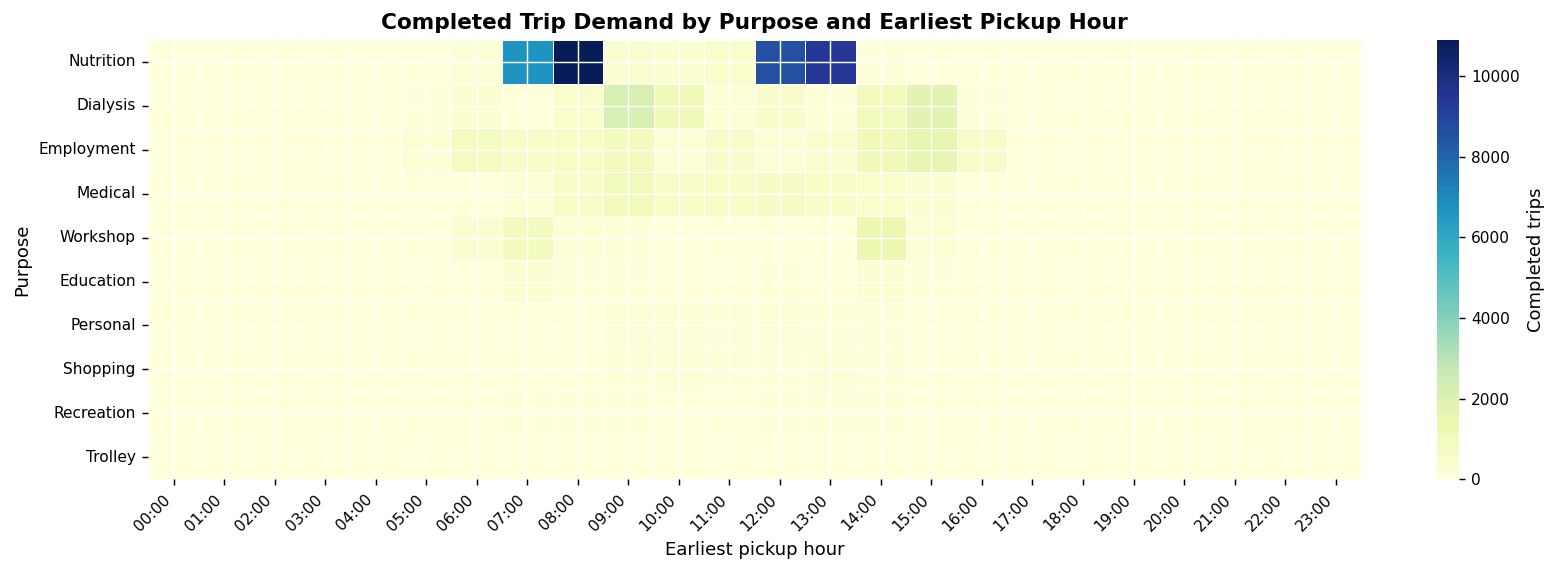

In [17]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

df_time_demand = df_clean.copy()
df_time_demand['pickup_hour'] = df_time_demand['Earliest Pick-up'].apply(hour_from_time)
df_time_demand = df_time_demand.dropna(subset=['Purpose', 'pickup_hour']).copy()
df_time_demand['pickup_hour'] = df_time_demand['pickup_hour'].astype(int)

purpose_hourly_demand = (
    df_time_demand
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

purpose_hourly_demand = purpose_hourly_demand.loc[
    purpose_hourly_demand.sum(axis=1).sort_values(ascending=False).index
]

print('Completed-trip demand by earliest pickup hour and purpose:')
display(purpose_hourly_demand.style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(13, max(3.5, 0.45 * len(purpose_hourly_demand))))
sns.heatmap(
    purpose_hourly_demand,
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Completed trips'},
    ax=ax,
)
ax.set_title('Completed Trip Demand by Purpose and Earliest Pickup Hour')
ax.set_xlabel('Earliest pickup hour')
ax.set_ylabel('Purpose')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout()


### Temporal Deviation Tolerance

This cell treats temporal deviation tolerance as experienced pickup time slack. For each completed trip, the actual pickup arrival is the `Reported Pick-up Arrival Time`.

First, for each matched trip, pickup slack is measured in minutes with a direct minus sign:

```text
time_slack_trip = actual_pickup_arrival_time - earliest_pickup_time
actual_pickup_arrival_time = Reported Pick-up Arrival Time
```

No absolute value is applied, so early arrivals remain negative in the raw trip-level slack. At the rider level, the accepted temporal slack tolerance is summarized by the 90th percentile of completed-trip slack and normalized by a 60-minute system limit:

```text
T_max_i = P90(time_slack_trip for all completed trips of rider i)
F_temp_i = min(max(T_max_i / T_sys_limit, 0), 1)
```

The temporal deviation tolerance is the normalized actual-minus-earliest pickup slack tolerance.


To verify the evidence to show the temporal/geographical/purpose flexibility index for individual;
Literature review to judge the measurements;

Simple assumption,

Trips with actual-minus-earliest time slack available: 63,596 / 63,596
Temporal tolerance setting: P90 of actual-minus-earliest slack, capped at 60 minutes
Customers with temporal deviation tolerance: 806
Customers in temporal deviation tolerance all-low group: 286
Customers in temporal deviation tolerance all-high group: 520


,count,mean,std,min,5%,25%,50%,75%,95%,max
time_slack_actual_minus_earliest_pickup_min,"63,596.00",14.38,22.93,-149.00,-17.00,0.00,12.00,26.00,54.00,426.00


,Customer Number,trip_frequency,trips_with_actual_pickup_arrival,average_time_slack_min,median_time_slack_min,time_slack_tolerance_min,actual_pickup_arrival_rate,time_slack_tolerance_norm,average_time_slack_norm,temporal_deviation_tolerance,temporal_deviation_tolerance_level,temporal_deviation_tolerance_profile,temporal_deviation_tolerance_all_low_flag,temporal_deviation_tolerance_all_high_flag
699,22004,148,148,39.76,37.00,83.30,100.0%,1.000,0.688,1.000,high,time_slack_tolerance_norm=high,False,True
613,19549,122,122,22.98,19.50,61.50,100.0%,1.000,0.518,1.000,high,time_slack_tolerance_norm=high,False,True
582,18616,110,110,17.81,17.00,62.40,100.0%,1.000,0.465,1.000,high,time_slack_tolerance_norm=high,False,True
722,22471,107,107,32.67,27.00,67.00,100.0%,1.000,0.616,1.000,high,time_slack_tolerance_norm=high,False,True
324,7644,101,101,31.49,29.00,68.00,100.0%,1.000,0.604,1.000,high,time_slack_tolerance_norm=high,False,True
486,12703,95,95,18.04,14.00,62.40,100.0%,1.000,0.467,1.000,high,time_slack_tolerance_norm=high,False,True
108,6527,88,88,17.10,6.50,66.70,100.0%,1.000,0.458,1.000,high,time_slack_tolerance_norm=high,False,True
733,22607,74,74,26.53,22.50,67.00,100.0%,1.000,0.554,1.000,high,time_slack_tolerance_norm=high,False,True
96,6393,67,67,63.30,70.00,92.60,100.0%,1.000,0.927,1.000,high,time_slack_tolerance_norm=high,False,True
168,7008,67,67,25.79,22.00,70.20,100.0%,1.000,0.546,1.000,high,time_slack_tolerance_norm=high,False,True


,component,level,customer_count,customer_share
0,temporal_deviation_tolerance,high,520,64.5%
1,temporal_deviation_tolerance,low,286,35.5%


,temporal_deviation_tolerance_level,customer_count,mean_temporal_deviation_tolerance,mean_time_slack_tolerance_min,mean_trip_frequency,customer_share
0,high,520,0.736,45.15,90.5,64.5%
1,low,286,0.309,18.12,57.8,35.5%


,Customer Number,trip_frequency,average_time_slack_min,median_time_slack_min,time_slack_tolerance_min,time_slack_tolerance_norm,temporal_deviation_tolerance
58,5849,12,0.00,0.00,0.00,0.000,0.000
201,7220,4,-13.25,-9.50,-6.20,0.000,0.000
684,21546,4,-6.00,-6.50,-3.90,0.000,0.000
387,8022,3,-25.00,-14.00,-9.20,0.000,0.000
25,3130,2,-8.50,-8.50,-5.70,0.000,0.000
37,5587,2,-11.50,-11.50,-4.70,0.000,0.000
75,6099,2,-0.50,-0.50,-0.10,0.000,0.000
143,6825,2,-20.00,-20.00,-6.40,0.000,0.000
248,7390,2,-15.00,-15.00,-11.00,0.000,0.000
341,7698,2,-2.50,-2.50,-0.50,0.000,0.000


,Customer Number,trip_frequency,average_time_slack_min,median_time_slack_min,time_slack_tolerance_min,time_slack_tolerance_norm,temporal_deviation_tolerance
699,22004,148,39.76,37.00,83.30,1.000,1.000
613,19549,122,22.98,19.50,61.50,1.000,1.000
582,18616,110,17.81,17.00,62.40,1.000,1.000
722,22471,107,32.67,27.00,67.00,1.000,1.000
324,7644,101,31.49,29.00,68.00,1.000,1.000
486,12703,95,18.04,14.00,62.40,1.000,1.000
108,6527,88,17.10,6.50,66.70,1.000,1.000
733,22607,74,26.53,22.50,67.00,1.000,1.000
96,6393,67,63.30,70.00,92.60,1.000,1.000
168,7008,67,25.79,22.00,70.20,1.000,1.000


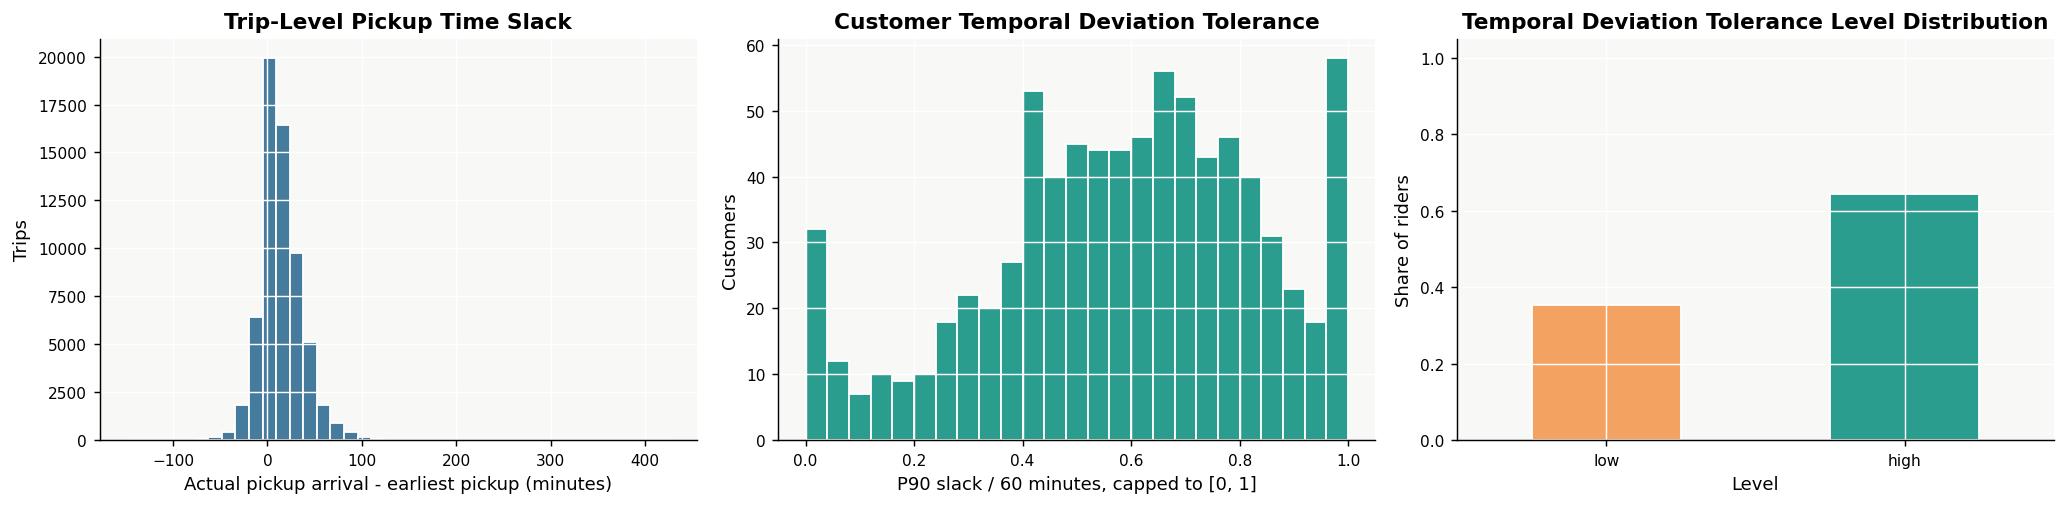

In [19]:
TEMPORAL_TOLERANCE_QUANTILE = 0.90
TEMPORAL_SYSTEM_LIMIT_MIN = 60.0

temporal_deviation_tolerance_trips = df_clean.copy()


def combine_trip_date_time(df, time_col):
    trip_dates = pd.to_datetime(df['Trip Date'], errors='coerce').dt.normalize()
    values = df[time_col]

    if pd.api.types.is_datetime64_any_dtype(values):
        return pd.to_datetime(values, errors='coerce', utc=True).dt.tz_convert(None)

    value_text = values.astype(str).str.strip()
    parsed_time = pd.to_datetime(value_text, errors='coerce', utc=True).dt.tz_convert(None)
    time_delta = pd.to_timedelta(value_text, errors='coerce')
    parsed_time_delta = parsed_time - parsed_time.dt.normalize()
    time_delta = time_delta.fillna(parsed_time_delta)
    combined = trip_dates + time_delta

    has_explicit_date = value_text.str.contains(r'\d{4}[-/]\d{1,2}[-/]\d{1,2}', na=False)
    combined.loc[has_explicit_date & parsed_time.notna()] = parsed_time.loc[
        has_explicit_date & parsed_time.notna()
    ]
    return combined


temporal_deviation_tolerance_trips['earliest_pickup_timestamp'] = combine_trip_date_time(
    temporal_deviation_tolerance_trips,
    'Earliest Pick-up',
)
temporal_deviation_tolerance_trips['actual_pickup_arrival_timestamp'] = combine_trip_date_time(
    temporal_deviation_tolerance_trips,
    'Reported Pick-up Arrival Time',
)

# Keep the reported-name alias so the data source for actual arrival is explicit.
temporal_deviation_tolerance_trips['reported_pickup_arrival_timestamp'] = (
    temporal_deviation_tolerance_trips['actual_pickup_arrival_timestamp']
)
# Temporal slack is measured with a direct minus sign: actual pickup arrival minus earliest pickup.
temporal_deviation_tolerance_trips['time_slack_actual_minus_earliest_pickup_min'] = (
    temporal_deviation_tolerance_trips['actual_pickup_arrival_timestamp']
    - temporal_deviation_tolerance_trips['earliest_pickup_timestamp']
).dt.total_seconds() / 60


def minmax_normalize_series(s):
    s = s.astype(float)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)


def temporal_level(value):
    if pd.isna(value):
        return np.nan
    if 0 <= value <= 0.5:
        return 'low'
    if 0.5 < value <= 1:
        return 'high'
    return np.nan


def temporal_tolerance_quantile(s):
    values = s.dropna()
    if values.empty:
        return np.nan
    return values.quantile(TEMPORAL_TOLERANCE_QUANTILE)


customer_temporal_deviation_tolerance = (
    temporal_deviation_tolerance_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        trips_with_actual_pickup_arrival=('actual_pickup_arrival_timestamp', 'count'),
        average_time_slack_min=('time_slack_actual_minus_earliest_pickup_min', 'mean'),
        median_time_slack_min=('time_slack_actual_minus_earliest_pickup_min', 'median'),
        time_slack_tolerance_min=('time_slack_actual_minus_earliest_pickup_min', temporal_tolerance_quantile),
    )
    .reset_index()
)
customer_temporal_deviation_tolerance['actual_pickup_arrival_rate'] = (
    customer_temporal_deviation_tolerance['trips_with_actual_pickup_arrival']
    / customer_temporal_deviation_tolerance['trip_frequency']
)
customer_temporal_deviation_tolerance['time_slack_tolerance_norm'] = (
    customer_temporal_deviation_tolerance['time_slack_tolerance_min']
    / TEMPORAL_SYSTEM_LIMIT_MIN
).clip(lower=0.0, upper=1.0)
customer_temporal_deviation_tolerance['average_time_slack_norm'] = minmax_normalize_series(
    customer_temporal_deviation_tolerance['average_time_slack_min']
)
customer_temporal_deviation_tolerance['temporal_deviation_tolerance'] = (
    customer_temporal_deviation_tolerance['time_slack_tolerance_norm']
)
customer_temporal_deviation_tolerance['temporal_deviation_tolerance_level'] = (
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance'].apply(temporal_level)
)
customer_temporal_deviation_tolerance['temporal_deviation_tolerance_profile'] = (
    'time_slack_tolerance_norm='
    + customer_temporal_deviation_tolerance['temporal_deviation_tolerance_level'].astype(str)
)
customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_low_flag'] = (
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance_level'].eq('low')
)
customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_high_flag'] = (
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance_level'].eq('high')
)

temporal_component_distribution = (
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance_level']
    .value_counts(dropna=False)
    .rename_axis('level')
    .reset_index(name='customer_count')
    .assign(component='temporal_deviation_tolerance')
)
temporal_component_distribution['customer_share'] = (
    temporal_component_distribution['customer_count']
    / temporal_component_distribution['customer_count'].sum()
)
temporal_component_distribution = temporal_component_distribution[
    ['component', 'level', 'customer_count', 'customer_share']
].sort_values('level')

temporal_group_summary = (
    customer_temporal_deviation_tolerance
    .groupby('temporal_deviation_tolerance_level', dropna=False)
    .agg(
        customer_count=('Customer Number', 'count'),
        mean_temporal_deviation_tolerance=('temporal_deviation_tolerance', 'mean'),
        mean_time_slack_tolerance_min=('time_slack_tolerance_min', 'mean'),
        mean_trip_frequency=('trip_frequency', 'mean'),
    )
    .reset_index()
    .sort_values('customer_count', ascending=False)
)
temporal_group_summary['customer_share'] = (
    temporal_group_summary['customer_count'] / len(customer_temporal_deviation_tolerance)
)

temporal_all_low_customers = customer_temporal_deviation_tolerance.loc[
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_low_flag'],
    [
        'Customer Number', 'trip_frequency', 'average_time_slack_min',
        'median_time_slack_min', 'time_slack_tolerance_min',
        'time_slack_tolerance_norm', 'temporal_deviation_tolerance',
    ]
].sort_values(['temporal_deviation_tolerance', 'trip_frequency'], ascending=[True, False])

temporal_all_high_customers = customer_temporal_deviation_tolerance.loc[
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_high_flag'],
    [
        'Customer Number', 'trip_frequency', 'average_time_slack_min',
        'median_time_slack_min', 'time_slack_tolerance_min',
        'time_slack_tolerance_norm', 'temporal_deviation_tolerance',
    ]
].sort_values(['temporal_deviation_tolerance', 'trip_frequency'], ascending=[False, False])

arrival_timing_check = (
    temporal_deviation_tolerance_trips[[
        'time_slack_actual_minus_earliest_pickup_min',
    ]]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)

customer_temporal_deviation_tolerance = customer_temporal_deviation_tolerance.sort_values(
    ['temporal_deviation_tolerance', 'trip_frequency'], ascending=[False, False]
)

print(
    f"Trips with actual-minus-earliest time slack available: "
    f"{temporal_deviation_tolerance_trips['time_slack_actual_minus_earliest_pickup_min'].notna().sum():,} / "
    f"{len(temporal_deviation_tolerance_trips):,}"
)
print(
    f"Temporal tolerance setting: P{TEMPORAL_TOLERANCE_QUANTILE * 100:.0f} "
    f"of actual-minus-earliest slack, capped at {TEMPORAL_SYSTEM_LIMIT_MIN:.0f} minutes"
)
print(f"Customers with temporal deviation tolerance: {customer_temporal_deviation_tolerance['temporal_deviation_tolerance'].notna().sum():,}")
print(f"Customers in temporal deviation tolerance all-low group: {int(customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_low_flag'].sum()):,}")
print(f"Customers in temporal deviation tolerance all-high group: {int(customer_temporal_deviation_tolerance['temporal_deviation_tolerance_all_high_flag'].sum()):,}")

display(arrival_timing_check.style.format('{:,.2f}'))
display(customer_temporal_deviation_tolerance.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'trips_with_actual_pickup_arrival': '{:,.0f}',
    'actual_pickup_arrival_rate': '{:.1%}',
    'average_time_slack_min': '{:,.2f}',
    'median_time_slack_min': '{:,.2f}',
    'time_slack_tolerance_min': '{:,.2f}',
    'time_slack_tolerance_norm': '{:.3f}',
    'average_time_slack_norm': '{:.3f}',
    'temporal_deviation_tolerance': '{:.3f}',
}))
display(temporal_component_distribution.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
}))
display(temporal_group_summary.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
    'mean_temporal_deviation_tolerance': '{:.3f}',
    'mean_time_slack_tolerance_min': '{:,.2f}',
    'mean_trip_frequency': '{:,.1f}',
}))
display(temporal_all_low_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'average_time_slack_min': '{:,.2f}',
    'median_time_slack_min': '{:,.2f}',
    'time_slack_tolerance_min': '{:,.2f}',
    'time_slack_tolerance_norm': '{:.3f}',
    'temporal_deviation_tolerance': '{:.3f}',
}))
display(temporal_all_high_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'average_time_slack_min': '{:,.2f}',
    'median_time_slack_min': '{:,.2f}',
    'time_slack_tolerance_min': '{:,.2f}',
    'time_slack_tolerance_norm': '{:.3f}',
    'temporal_deviation_tolerance': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    temporal_deviation_tolerance_trips['time_slack_actual_minus_earliest_pickup_min'].dropna(),
    bins=40,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Trip-Level Pickup Time Slack')
axes[0].set_xlabel('Actual pickup arrival - earliest pickup (minutes)')
axes[0].set_ylabel('Trips')

axes[1].hist(
    customer_temporal_deviation_tolerance['temporal_deviation_tolerance'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[1].set_title('Customer Temporal Deviation Tolerance')
axes[1].set_xlabel('P90 slack / 60 minutes, capped to [0, 1]')
axes[1].set_ylabel('Customers')

temporal_level_plot = (
    temporal_component_distribution
    .set_index('level')['customer_share']
    .reindex(['low', 'high'])
    .fillna(0)
)
temporal_level_plot.plot(
    kind='bar',
    ax=axes[2],
    color=['#f4a261', '#2a9d8f'],
    edgecolor='white',
)
axes[2].set_title('Temporal Deviation Tolerance Level Distribution')
axes[2].set_xlabel('Level')
axes[2].set_ylabel('Share of riders')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Geographical Flexibility Index

This section now uses only destination substitutability. Origin deviation is excluded because it requires an OSMnx/Overpass walk-network graph that is not consistently available in this environment, and treating missing origin-network evidence as zero would bias the index downward.

```text
geographical_flexibility_index = F_dest_sub
```

Destination substitutability uses `birmingham_pois.csv` as the POI database. Each historical destination is semantically tagged by POI category using this hierarchy:

1. normalized full drop-off address match
2. normalized street-address match
3. recorded `Drop-off POI Name` match when available
4. nearest POI by drop-off latitude/longitude within `NEAREST_DESTINATION_POI_RADIUS_M`

For each trip with a destination category, the notebook searches around the trip origin for same-category alternative POIs and calculates:

```text
Q_i = sum_{a in A_i} 1 / (1 + d_a / d_hist)
F_geo(i) = Q_i / (1 + Q_i)
```

Here, `A_i` is the set of same-category alternative POIs within the destination-substitutability search radius, `d_a` is the distance from the trip origin to alternative POI `a`, and `d_hist` is the observed origin-to-destination distance for the historical trip.

For rigid purposes such as medical, dialysis, work, or employment, destination alternatives are forced to zero because the specific destination is usually not substitutable.

The notebook also reports POI coverage diagnostics so low match rates can be interpreted as address/name mismatch, missing workbook POI names, missing locations in `birmingham_pois.csv`, or coordinate matches outside the search radius.


Customers in geographical flexibility analysis: 806
Geographical flexibility index uses destination substitutability only.
Unique historical destinations assigned a POI category: 434 / 1,477
Destination alternative search radius: 3.0 mile(s); gamma=0.35
Customers in geographical all-low group: 621
Customers in geographical all-high group: 42
Destination POI match method summary:


,match_method,unique_destination_count,share_of_unique_destinations
0,none,"1,043",70.6%
1,coordinate,260,17.6%
2,address,134,9.1%
3,street_address,24,1.6%
4,dropoff_poi_name,16,1.1%


Destination POI coverage diagnostics:


,coverage_reason,unique_destination_count,share_of_unique_destinations
0,no_workbook_poi_name_and_address_not_in_poi_file,661,44.8%
1,matched_to_poi_category,434,29.4%
2,recorded_poi_name_not_in_poi_file,382,25.9%


,Customer Number,trip_frequency,destination_substitutability_index,geographical_flexibility_raw,geographical_flexibility_index,avg_destination_alternative_poi_count,avg_historical_origin_destination_distance_m,avg_closest_destination_alternative_distance_m,num_destination_categories,destination_category_match_rate,address_destination_poi_match_rate,named_destination_poi_match_rate,coordinate_destination_poi_match_rate,dominant_destination_purpose,destination_substitutability_index_level,geographical_flexibility_level,geographical_profile,geographical_all_low_flag,geographical_all_high_flag
451,9059,43,0.982,0.982,0.982,207.4,"4,012.7",73.3,1,100.0%,48.8%,0.0%,51.2%,nutrition,high,high,destination_substitutability_index=high,False,True
110,6547,43,0.978,0.978,0.978,166.0,"1,349.2",29.4,1,100.0%,0.0%,0.0%,100.0%,nutrition,high,high,destination_substitutability_index=high,False,True
102,6445,43,0.976,0.976,0.976,166.0,"1,240.9",29.4,1,100.0%,0.0%,0.0%,100.0%,nutrition,high,high,destination_substitutability_index=high,False,True
578,18518,111,0.964,0.964,0.964,209.4,"3,791.6",137.7,1,100.0%,48.6%,0.0%,51.4%,nutrition,high,high,destination_substitutability_index=high,False,True
73,6069,113,0.959,0.959,0.959,218.5,"2,694.3",86.2,1,100.0%,50.4%,0.0%,49.6%,nutrition,high,high,destination_substitutability_index=high,False,True
485,12551,7,0.952,0.952,0.952,201.6,"1,674.3",79.7,1,100.0%,28.6%,0.0%,71.4%,nutrition,high,high,destination_substitutability_index=high,False,True
638,20134,44,0.913,0.913,0.913,33.0,"1,576.9",137.4,1,100.0%,0.0%,0.0%,100.0%,nutrition,high,high,destination_substitutability_index=high,False,True
207,7249,130,0.912,0.912,0.912,21.6,"3,530.0",307.5,2,100.0%,51.5%,0.0%,48.5%,nutrition,high,high,destination_substitutability_index=high,False,True
388,8023,84,0.874,0.874,0.874,111.5,"2,566.8",323.9,1,50.0%,50.0%,0.0%,0.0%,nutrition,high,high,destination_substitutability_index=high,False,True
682,21407,258,0.869,0.869,0.869,24.5,"3,693.8",373.4,2,100.0%,50.0%,0.0%,50.0%,nutrition,high,high,destination_substitutability_index=high,False,True


,component,level,customer_count,customer_share
2,destination_substitutability_index,high,42,5.2%
0,destination_substitutability_index,low,621,77.0%
1,destination_substitutability_index,nan,143,17.7%


,destination_substitutability_index_level,customer_count,mean_destination_substitutability_index,mean_geographical_flexibility_index,mean_trip_frequency,customer_share
1,low,621,0.027,0.027,59.7,77.0%
2,nan,143,nan,nan,147.6,17.7%
0,high,42,0.749,0.749,129.0,5.2%


,Customer Number,trip_frequency,destination_substitutability_index,geographical_flexibility_raw,geographical_flexibility_index
120,6643,475,0.000,0.000,0.000
175,7057,469,0.000,0.000,0.000
44,5703,454,0.000,0.000,0.000
7,1138,439,0.000,0.000,0.000
762,23155,418,0.000,0.000,0.000
546,16677,395,0.000,0.000,0.000
121,6651,393,0.000,0.000,0.000
216,7281,386,0.000,0.000,0.000
596,19110,376,0.000,0.000,0.000
513,14909,357,0.000,0.000,0.000


,Customer Number,trip_frequency,destination_substitutability_index,geographical_flexibility_raw,geographical_flexibility_index
451,9059,43,0.982,0.982,0.982
110,6547,43,0.978,0.978,0.978
102,6445,43,0.976,0.976,0.976
578,18518,111,0.964,0.964,0.964
73,6069,113,0.959,0.959,0.959
485,12551,7,0.952,0.952,0.952
638,20134,44,0.913,0.913,0.913
207,7249,130,0.912,0.912,0.912
388,8023,84,0.874,0.874,0.874
682,21407,258,0.869,0.869,0.869


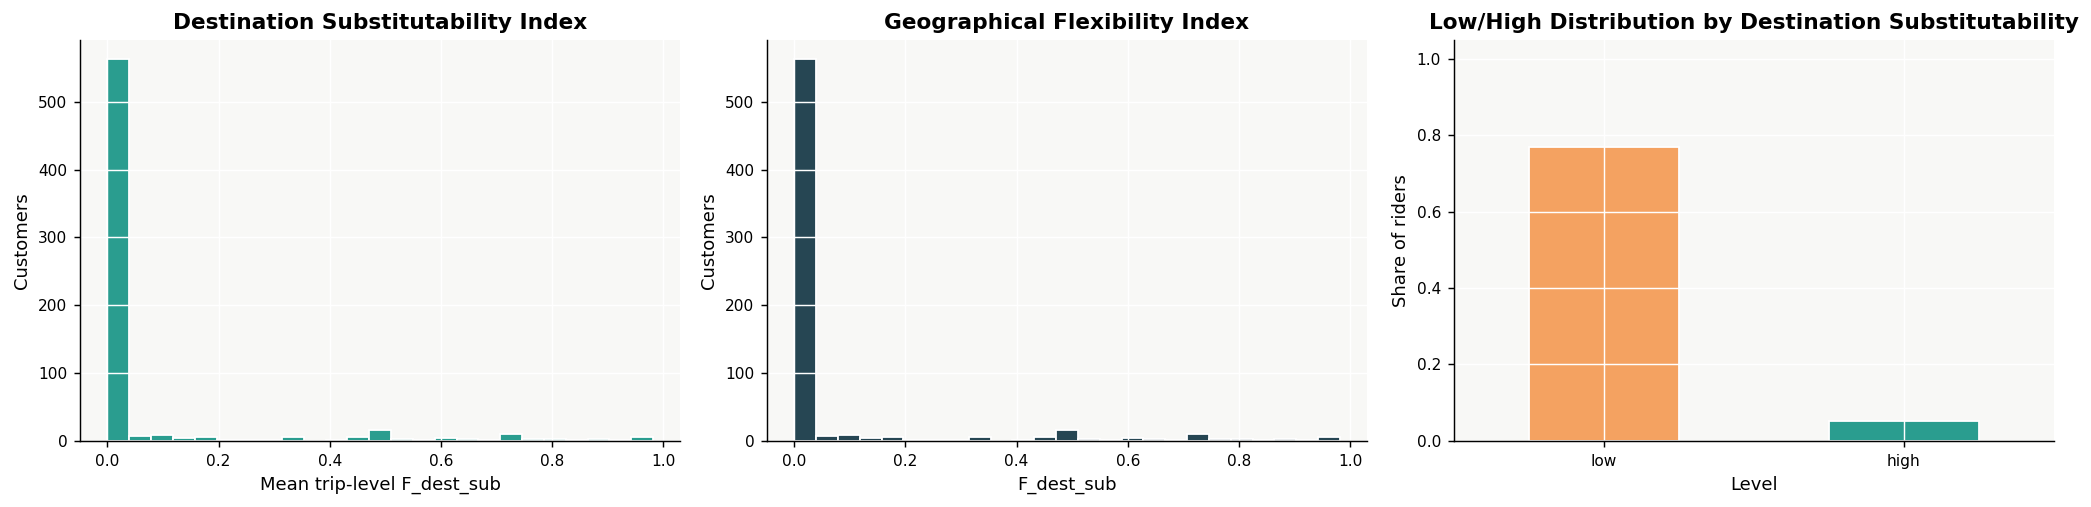

In [26]:
GEOGRAPHICAL_WEIGHT_DEST_SUB = 1.0
DESTINATION_SUBSTITUTABILITY_RADIUS_M = 4828.03  # 3 miles around the origin.
NEAREST_DESTINATION_POI_RADIUS_M = 250.0
SELF_DESTINATION_POI_EXCLUSION_RADIUS_M = 25.0
NON_SUBSTITUTABLE_DESTINATION_PURPOSES = {
    'dialysis', 'medical', 'medical appointment', 'employment', 'work'
}

POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_geo = pd.read_csv(POI_PATH).dropna(subset=['lat']).copy()
POI_LON_COL = 'lon' if 'lon' in poi_geo.columns else 'lng'
poi_geo = poi_geo.dropna(subset=[POI_LON_COL]).copy()
poi_geo['poi_name'] = poi_geo.get('name', '').fillna('').astype(str)
poi_geo['poi_top_category'] = poi_geo.get('top_category', '').fillna('').astype(str)
poi_geo['poi_sub_category'] = poi_geo.get('sub_category', '').fillna('').astype(str)
if 'poi_id' not in poi_geo.columns:
    poi_geo['poi_id'] = poi_geo.index.astype(str)


def haversine_matrix_m(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    return 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000


def haversine_distance_m(lat1, lon1, lat2, lon2):
    return haversine_matrix_m([lat1], [lon1], [lat2], [lon2])[0, 0]


def normalize_match_text(value):
    if pd.isna(value):
        return ''
    text = str(value).lower().strip().replace('.0', '')
    replacements = {
        '&': ' and ',
        '.': ' ', ',': ' ', '#': ' ', '-': ' ', '/': ' ',
        ' street ': ' st ', ' avenue ': ' ave ', ' road ': ' rd ',
        ' boulevard ': ' blvd ', ' drive ': ' dr ', ' lane ': ' ln ',
        ' court ': ' ct ', ' highway ': ' hwy ', ' parkway ': ' pkwy ',
        ' north ': ' n ', ' south ': ' s ', ' east ': ' e ', ' west ': ' w ',
    }
    text = f' {text} '
    for old, new in replacements.items():
        text = text.replace(old, new)
    return ' '.join(text.split())


def first_nonblank(values):
    for value in values:
        text = '' if pd.isna(value) else str(value).strip()
        if text:
            return text
    return ''


def build_poi_full_address(row):
    return ' '.join([
        str(row.get('address', '')),
        str(row.get('city', '')),
        str(row.get('region', '')),
        str(row.get('zipcode', '')),
    ])


def geographical_level(value):
    if pd.isna(value):
        return np.nan
    if 0 <= value <= 0.5:
        return 'low'
    if 0.5 < value <= 1:
        return 'high'
    return np.nan


def normalize_purpose_label(purpose):
    text = '' if pd.isna(purpose) else str(purpose).strip().lower()
    if 'medical' in text:
        return 'medical'
    if 'dialysis' in text:
        return 'dialysis'
    if 'work' in text or 'employment' in text:
        return 'work'
    return text


def poi_destination_category_key(row):
    naics = row.get('naics', np.nan)
    if pd.notna(naics) and str(naics).strip():
        return 'naics:' + str(naics).strip().replace('.0', '')
    top_category = str(row.get('poi_top_category', '')).strip().lower()
    sub_category = str(row.get('poi_sub_category', '')).strip().lower()
    if top_category or sub_category:
        return 'category:' + top_category + '|' + sub_category
    return np.nan


poi_geo['destination_category_key'] = poi_geo.apply(poi_destination_category_key, axis=1)
poi_geo['poi_full_address_key'] = poi_geo.apply(
    lambda row: normalize_match_text(build_poi_full_address(row)), axis=1
)
poi_geo['poi_street_address_key'] = poi_geo.get('address', '').fillna('').apply(normalize_match_text)
poi_geo['poi_name_key'] = poi_geo['poi_name'].apply(normalize_match_text)


def make_poi_lookup(key_col):
    valid = poi_geo.loc[poi_geo[key_col].astype(str).str.len() > 0].drop_duplicates(key_col)
    return {row[key_col]: row for _, row in valid.iterrows()}


poi_lookup_by_full_address = make_poi_lookup('poi_full_address_key')
poi_lookup_by_street_address = make_poi_lookup('poi_street_address_key')
poi_lookup_by_name = make_poi_lookup('poi_name_key')

geography_trips = df_clean.copy()
optional_destination_cols = [
    col for col in ['Drop-off POI Name']
    if col not in geography_trips.columns and col in df_raw.columns
]
if optional_destination_cols and 'Trip ID' in df_raw.columns:
    destination_lookup = df_raw[['Trip ID'] + optional_destination_cols].drop_duplicates('Trip ID')
    geography_trips = geography_trips.merge(destination_lookup, on='Trip ID', how='left')

if 'Drop-off POI Name' not in geography_trips.columns:
    geography_trips['Drop-off POI Name'] = ''
geography_trips['dropoff_poi_name_clean'] = geography_trips['Drop-off POI Name'].fillna('').astype(str).str.strip()
geography_trips['normalized_destination_purpose'] = geography_trips['Purpose'].apply(normalize_purpose_label)
geography_trips['destination_is_non_substitutable'] = (
    geography_trips['normalized_destination_purpose'].isin(NON_SUBSTITUTABLE_DESTINATION_PURPOSES)
)

unique_historical_destinations = (
    geography_trips
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'], dropna=False)
    .agg(dropoff_poi_name=('dropoff_poi_name_clean', first_nonblank))
    .reset_index()
)
unique_historical_destinations['dropoff_address_key'] = (
    unique_historical_destinations['dropoff_address'].apply(normalize_match_text)
)
unique_historical_destinations['dropoff_street_address_key'] = (
    unique_historical_destinations['dropoff_address']
    .fillna('')
    .astype(str)
    .str.split(',', n=1)
    .str[0]
    .apply(normalize_match_text)
)
unique_historical_destinations['dropoff_poi_name_key'] = (
    unique_historical_destinations['dropoff_poi_name'].apply(normalize_match_text)
)
unique_historical_destinations['has_recorded_dropoff_poi_name'] = (
    unique_historical_destinations['dropoff_poi_name_key'].str.len() > 0
)
unique_historical_destinations['address_key_in_poi_file'] = (
    unique_historical_destinations['dropoff_address_key'].isin(poi_lookup_by_full_address)
)
unique_historical_destinations['street_address_key_in_poi_file'] = (
    unique_historical_destinations['dropoff_street_address_key'].isin(poi_lookup_by_street_address)
)
unique_historical_destinations['poi_name_key_in_poi_file'] = (
    unique_historical_destinations['dropoff_poi_name_key'].isin(poi_lookup_by_name)
)

address_name_match_records = []
for row in unique_historical_destinations.itertuples(index=False):
    matched_poi = None
    match_method = 'none'
    for key_value, poi_lookup, method in [
        (row.dropoff_address_key, poi_lookup_by_full_address, 'address'),
        (row.dropoff_street_address_key, poi_lookup_by_street_address, 'street_address'),
        (row.dropoff_poi_name_key, poi_lookup_by_name, 'dropoff_poi_name'),
    ]:
        if key_value and key_value in poi_lookup:
            matched_poi = poi_lookup[key_value]
            match_method = method
            break

    if matched_poi is None:
        address_name_match_records.append({
            'nearest_destination_poi_id': np.nan,
            'nearest_destination_poi_name': np.nan,
            'nearest_destination_poi_distance_m': np.nan,
            'historical_destination_category_key': np.nan,
            'destination_poi_match_method': 'none',
        })
    else:
        address_name_match_records.append({
            'nearest_destination_poi_id': matched_poi['poi_id'],
            'nearest_destination_poi_name': matched_poi['poi_name'],
            'nearest_destination_poi_distance_m': haversine_distance_m(
                row.dropoff_lat, row.dropoff_lon, matched_poi['lat'], matched_poi[POI_LON_COL]
            ),
            'historical_destination_category_key': matched_poi['destination_category_key'],
            'destination_poi_match_method': match_method,
        })

unique_historical_destinations = pd.concat(
    [unique_historical_destinations, pd.DataFrame(address_name_match_records)], axis=1
)

coordinate_unmatched = unique_historical_destinations['historical_destination_category_key'].isna()
unique_historical_destinations['nearest_coordinate_poi_distance_m'] = np.nan
if coordinate_unmatched.any():
    unmatched_destinations = unique_historical_destinations.loc[coordinate_unmatched]
    destination_poi_distances_m = haversine_matrix_m(
        unmatched_destinations['dropoff_lat'],
        unmatched_destinations['dropoff_lon'],
        poi_geo['lat'],
        poi_geo[POI_LON_COL],
    )
    nearest_destination_poi_idx = destination_poi_distances_m.argmin(axis=1)
    nearest_destination_poi_distance_m = destination_poi_distances_m[
        np.arange(len(unmatched_destinations)), nearest_destination_poi_idx
    ]
    nearest_destination_pois = poi_geo.iloc[nearest_destination_poi_idx].reset_index(drop=True)
    nearest_destination_poi_matched = nearest_destination_poi_distance_m <= NEAREST_DESTINATION_POI_RADIUS_M
    unmatched_index = unmatched_destinations.index.to_numpy()
    matched_index = unmatched_index[nearest_destination_poi_matched]

    unique_historical_destinations.loc[unmatched_index, 'nearest_coordinate_poi_distance_m'] = (
        nearest_destination_poi_distance_m
    )
    unique_historical_destinations.loc[unmatched_index, 'nearest_destination_poi_distance_m'] = (
        nearest_destination_poi_distance_m
    )
    unique_historical_destinations.loc[matched_index, 'nearest_destination_poi_id'] = (
        nearest_destination_pois.loc[nearest_destination_poi_matched, 'poi_id'].to_numpy()
    )
    unique_historical_destinations.loc[matched_index, 'nearest_destination_poi_name'] = (
        nearest_destination_pois.loc[nearest_destination_poi_matched, 'poi_name'].to_numpy()
    )
    unique_historical_destinations.loc[matched_index, 'historical_destination_category_key'] = (
        nearest_destination_pois.loc[nearest_destination_poi_matched, 'destination_category_key'].to_numpy()
    )
    unique_historical_destinations.loc[matched_index, 'destination_poi_match_method'] = 'coordinate'


def classify_unmatched_destination_reason(row):
    if pd.notna(row['historical_destination_category_key']):
        return 'matched_to_poi_category'
    if not row['has_recorded_dropoff_poi_name'] and not row['address_key_in_poi_file'] and not row['street_address_key_in_poi_file']:
        return 'no_workbook_poi_name_and_address_not_in_poi_file'
    if row['has_recorded_dropoff_poi_name'] and not row['poi_name_key_in_poi_file']:
        return 'recorded_poi_name_not_in_poi_file'
    if not row['address_key_in_poi_file'] and not row['street_address_key_in_poi_file']:
        return 'dropoff_address_not_in_poi_file'
    if pd.notna(row['nearest_coordinate_poi_distance_m']) and row['nearest_coordinate_poi_distance_m'] > NEAREST_DESTINATION_POI_RADIUS_M:
        return 'nearest_poi_outside_coordinate_radius'
    return 'unmatched_other'


unique_historical_destinations['destination_poi_coverage_reason'] = (
    unique_historical_destinations.apply(classify_unmatched_destination_reason, axis=1)
)

destination_poi_match_summary = (
    unique_historical_destinations['destination_poi_match_method']
    .value_counts(dropna=False)
    .rename_axis('match_method')
    .reset_index(name='unique_destination_count')
)
destination_poi_match_summary['share_of_unique_destinations'] = (
    destination_poi_match_summary['unique_destination_count'] / len(unique_historical_destinations)
)

destination_poi_coverage_diagnostics = (
    unique_historical_destinations['destination_poi_coverage_reason']
    .value_counts(dropna=False)
    .rename_axis('coverage_reason')
    .reset_index(name='unique_destination_count')
)
destination_poi_coverage_diagnostics['share_of_unique_destinations'] = (
    destination_poi_coverage_diagnostics['unique_destination_count'] / len(unique_historical_destinations)
)

geography_trips = geography_trips.merge(
    unique_historical_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
        'nearest_destination_poi_id', 'nearest_destination_poi_name',
        'nearest_destination_poi_distance_m', 'historical_destination_category_key',
        'destination_poi_match_method', 'destination_poi_coverage_reason',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='left',
)
geography_trips['historical_origin_destination_distance_m'] = [
    haversine_distance_m(row.pickup_lat, row.pickup_lon, row.dropoff_lat, row.dropoff_lon)
    for row in geography_trips.itertuples(index=False)
]

alternative_key_cols = [
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
    'normalized_destination_purpose', 'destination_is_non_substitutable',
    'historical_destination_category_key', 'historical_origin_destination_distance_m',
]
destination_opportunities = (
    geography_trips[alternative_key_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)
poi_category_array = poi_geo['destination_category_key'].to_numpy()
poi_lat_array = poi_geo['lat'].to_numpy(dtype=float)
poi_lon_array = poi_geo[POI_LON_COL].to_numpy(dtype=float)

destination_alternative_counts = []
closest_destination_alternative_distances_m = []
destination_substitutability_q_values = []
destination_substitutability_scores = []
for row in destination_opportunities.itertuples(index=False):
    category_key = row.historical_destination_category_key
    d_hist = row.historical_origin_destination_distance_m

    if row.destination_is_non_substitutable:
        destination_alternative_counts.append(0)
        closest_destination_alternative_distances_m.append(np.nan)
        destination_substitutability_q_values.append(0.0)
        destination_substitutability_scores.append(0.0)
        continue

    if pd.isna(category_key) or pd.isna(d_hist) or d_hist <= 0:
        destination_alternative_counts.append(0)
        closest_destination_alternative_distances_m.append(np.nan)
        destination_substitutability_q_values.append(np.nan)
        destination_substitutability_scores.append(np.nan)
        continue

    same_category = poi_category_array == category_key
    if not same_category.any():
        destination_alternative_counts.append(0)
        closest_destination_alternative_distances_m.append(np.nan)
        destination_substitutability_q_values.append(0.0)
        destination_substitutability_scores.append(0.0)
        continue

    candidate_lat = poi_lat_array[same_category]
    candidate_lon = poi_lon_array[same_category]
    origin_to_candidate_m = haversine_matrix_m(
        [row.pickup_lat], [row.pickup_lon], candidate_lat, candidate_lon
    )[0]
    destination_to_candidate_m = haversine_matrix_m(
        [row.dropoff_lat], [row.dropoff_lon], candidate_lat, candidate_lon
    )[0]
    candidate_mask = (
        (origin_to_candidate_m <= DESTINATION_SUBSTITUTABILITY_RADIUS_M)
        & (destination_to_candidate_m > SELF_DESTINATION_POI_EXCLUSION_RADIUS_M)
    )
    n_alt = int(candidate_mask.sum())

    if n_alt == 0:
        d_alt = np.nan
        q_i = 0.0
        substitutability_score = 0.0
    else:
        alternative_distances_m = origin_to_candidate_m[candidate_mask]
        d_alt = float(alternative_distances_m.min())
        q_i = float((1 / (1 + (alternative_distances_m / float(d_hist)))).sum())
        substitutability_score = float(q_i / (1 + q_i))

    destination_alternative_counts.append(n_alt)
    closest_destination_alternative_distances_m.append(d_alt)
    destination_substitutability_q_values.append(q_i)
    destination_substitutability_scores.append(substitutability_score)

destination_opportunities['destination_alternative_poi_count'] = destination_alternative_counts
destination_opportunities['destination_substitutability_q'] = destination_substitutability_q_values
destination_opportunities['closest_destination_alternative_distance_m'] = (
    closest_destination_alternative_distances_m
)
destination_opportunities['destination_substitutability_index'] = destination_substitutability_scores

geography_trips = geography_trips.merge(
    destination_opportunities[
        alternative_key_cols
        + [
            'destination_alternative_poi_count',
            'destination_substitutability_q',
            'closest_destination_alternative_distance_m',
            'destination_substitutability_index',
        ]
    ],
    on=alternative_key_cols,
    how='left',
)

geography_trips['trip_geographical_flexibility_raw'] = geography_trips['destination_substitutability_index']
geography_trips['trip_geographical_flexibility_index'] = geography_trips['destination_substitutability_index']

customer_geographical_flexibility = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        destination_substitutability_index=('destination_substitutability_index', 'mean'),
        avg_destination_substitutability_q=('destination_substitutability_q', 'mean'),
        geographical_flexibility_raw=('trip_geographical_flexibility_raw', 'mean'),
        geographical_flexibility_index=('trip_geographical_flexibility_index', 'mean'),
        avg_destination_alternative_poi_count=('destination_alternative_poi_count', 'mean'),
        avg_historical_origin_destination_distance_m=('historical_origin_destination_distance_m', 'mean'),
        avg_closest_destination_alternative_distance_m=('closest_destination_alternative_distance_m', 'mean'),
        num_destination_categories=('historical_destination_category_key', 'nunique'),
        destination_category_match_rate=('historical_destination_category_key', lambda s: s.notna().mean()),
        address_destination_poi_match_rate=(
            'destination_poi_match_method', lambda s: s.isin(['address', 'street_address']).mean()
        ),
        named_destination_poi_match_rate=('destination_poi_match_method', lambda s: s.eq('dropoff_poi_name').mean()),
        coordinate_destination_poi_match_rate=('destination_poi_match_method', lambda s: s.eq('coordinate').mean()),
        dominant_destination_purpose=(
            'normalized_destination_purpose',
            lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan,
        ),
    )
    .reset_index()
)

customer_geographical_flexibility['destination_substitutability_index_level'] = (
    customer_geographical_flexibility['destination_substitutability_index'].apply(geographical_level)
)
customer_geographical_flexibility['geographical_flexibility_level'] = (
    customer_geographical_flexibility['geographical_flexibility_index'].apply(geographical_level)
)
customer_geographical_flexibility['geographical_profile'] = (
    'destination_substitutability_index='
    + customer_geographical_flexibility['destination_substitutability_index_level'].astype(str)
)
customer_geographical_flexibility['geographical_all_low_flag'] = (
    customer_geographical_flexibility['destination_substitutability_index_level'].eq('low')
)
customer_geographical_flexibility['geographical_all_high_flag'] = (
    customer_geographical_flexibility['destination_substitutability_index_level'].eq('high')
)

geographical_component_distribution = (
    customer_geographical_flexibility['destination_substitutability_index_level']
    .value_counts(dropna=False)
    .rename_axis('level')
    .reset_index(name='customer_count')
    .assign(component='destination_substitutability_index')
)
geographical_component_distribution['customer_share'] = (
    geographical_component_distribution['customer_count']
    / geographical_component_distribution['customer_count'].sum()
)
geographical_component_distribution = geographical_component_distribution[
    ['component', 'level', 'customer_count', 'customer_share']
].sort_values(['component', 'level'])

geographical_group_summary = (
    customer_geographical_flexibility
    .groupby('destination_substitutability_index_level', dropna=False)
    .agg(
        customer_count=('Customer Number', 'count'),
        mean_destination_substitutability_index=('destination_substitutability_index', 'mean'),
        mean_geographical_flexibility_index=('geographical_flexibility_index', 'mean'),
        mean_trip_frequency=('trip_frequency', 'mean'),
    )
    .reset_index()
    .sort_values('customer_count', ascending=False)
)
geographical_group_summary['customer_share'] = (
    geographical_group_summary['customer_count'] / len(customer_geographical_flexibility)
)

geographical_all_low_customers = customer_geographical_flexibility.loc[
    customer_geographical_flexibility['geographical_all_low_flag'],
    [
        'Customer Number', 'trip_frequency', 'destination_substitutability_index',
        'geographical_flexibility_raw', 'geographical_flexibility_index',
    ]
].sort_values(['geographical_flexibility_index', 'trip_frequency'], ascending=[True, False])

geographical_all_high_customers = customer_geographical_flexibility.loc[
    customer_geographical_flexibility['geographical_all_high_flag'],
    [
        'Customer Number', 'trip_frequency', 'destination_substitutability_index',
        'geographical_flexibility_raw', 'geographical_flexibility_index',
    ]
].sort_values(['geographical_flexibility_index', 'trip_frequency'], ascending=[False, False])

customer_geographical_flexibility = customer_geographical_flexibility.sort_values(
    ['geographical_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

radius_miles = DESTINATION_SUBSTITUTABILITY_RADIUS_M / 1609.34
print(f"Customers in geographical flexibility analysis: {len(customer_geographical_flexibility):,}")
print('Geographical flexibility index uses destination substitutability only.')
print(
    f"Unique historical destinations assigned a POI category: "
    f"{unique_historical_destinations['historical_destination_category_key'].notna().sum():,} / "
    f"{len(unique_historical_destinations):,}"
)
print(f"Destination alternative search radius: {radius_miles:.1f} mile(s)")
print(f"Customers in geographical all-low group: {int(customer_geographical_flexibility['geographical_all_low_flag'].sum()):,}")
print(f"Customers in geographical all-high group: {int(customer_geographical_flexibility['geographical_all_high_flag'].sum()):,}")

print('Destination POI match method summary:')
display(destination_poi_match_summary.style.format({
    'unique_destination_count': '{:,.0f}',
    'share_of_unique_destinations': '{:.1%}',
}))
print('Destination POI coverage diagnostics:')
display(destination_poi_coverage_diagnostics.style.format({
    'unique_destination_count': '{:,.0f}',
    'share_of_unique_destinations': '{:.1%}',
}))
display(customer_geographical_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'destination_substitutability_index': '{:.3f}',
    'avg_destination_substitutability_q': '{:,.3f}',
    'geographical_flexibility_raw': '{:.3f}',
    'geographical_flexibility_index': '{:.3f}',
    'avg_destination_alternative_poi_count': '{:,.1f}',
    'avg_historical_origin_destination_distance_m': '{:,.1f}',
    'avg_closest_destination_alternative_distance_m': '{:,.1f}',
    'num_destination_categories': '{:,.0f}',
    'destination_category_match_rate': '{:.1%}',
    'address_destination_poi_match_rate': '{:.1%}',
    'named_destination_poi_match_rate': '{:.1%}',
    'coordinate_destination_poi_match_rate': '{:.1%}',
}))
display(geographical_component_distribution.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
}))
display(geographical_group_summary.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
    'mean_destination_substitutability_index': '{:.3f}',
    'mean_geographical_flexibility_index': '{:.3f}',
    'mean_trip_frequency': '{:,.1f}',
}))
display(geographical_all_low_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'destination_substitutability_index': '{:.3f}',
    'geographical_flexibility_raw': '{:.3f}',
    'geographical_flexibility_index': '{:.3f}',
}))
display(geographical_all_high_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'destination_substitutability_index': '{:.3f}',
    'geographical_flexibility_raw': '{:.3f}',
    'geographical_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    customer_geographical_flexibility['destination_substitutability_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[0].set_title('Destination Substitutability Index')
axes[0].set_xlabel('Mean trip-level F_dest_sub')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_geographical_flexibility['geographical_flexibility_index'].dropna(),
    bins=25,
    color='#264653',
    edgecolor='white',
)
axes[1].set_title('Geographical Flexibility Index')
axes[1].set_xlabel('F_dest_sub')
axes[1].set_ylabel('Customers')

geographical_level_plot = (
    geographical_component_distribution
    .set_index('level')['customer_share']
    .reindex(['low', 'high'])
    .fillna(0)
)
geographical_level_plot.plot(
    kind='bar',
    ax=axes[2],
    color=['#f4a261', '#2a9d8f'],
    edgecolor='white',
)
axes[2].set_title('Low/High Distribution by Destination Substitutability')
axes[2].set_xlabel('Level')
axes[2].set_ylabel('Share of riders')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Purpose Flexibility Index

This cell replaces the earlier purpose-diversity / non-urgency / substitutability implementation. Purpose flexibility is now a direct shiftability score inferred from the SafeGraph POI category nearest to each completed trip's drop-off coordinate.

```text
F_purpose_i = assigned shiftability weight for trip i's POI category
```

Step 1, extract the POI category. The notebook cross-references each historical drop-off coordinate with `birmingham_pois.csv`, using the nearest POI within `NEAREST_PURPOSE_POI_RADIUS_M`. The matched POI's NAICS code and category text are used as the semantic purpose category. If no nearby POI is found, the recorded Ecolane `Purpose` is used as a fallback label.

Step 2, assign the shiftability weight:

```text
0.00 = perfectly rigid: dialysis, emergency medical, shift-work employment, school/education
0.33 = low flexibility: routine medical, bank appointments, official government services
0.66 = moderate flexibility: gym/recreation, visiting family, general retail
1.00 = highly flexible: grocery shopping, parks, dining
```

The rider-level purpose flexibility index is the mean trip-level shiftability score:

```text
purpose_flexibility_index_u = mean(F_purpose_i for all completed trips of rider u)
```

A higher value means the rider's historical destinations tend to support more shiftable trip purposes.


Customers in purpose flexibility analysis: 806
Unique destination-purpose locations matched to nearby POIs: 516 / 1,852
Nearest POI category radius: 250 meters
Customers in purpose all-low group: 519
Customers in purpose all-high group: 287
Trip-level purpose shiftability distribution:


,purpose_shiftability_class,trip_count,trip_share
0,moderate_flexibility,"33,334",52.4%
1,perfectly_rigid,"20,795",32.7%
2,low_flexibility,"6,639",10.4%
3,highly_flexible,"2,828",4.4%


Top riders by purpose flexibility index:


,Customer Number,trip_frequency,purpose_flexibility_index,median_purpose_flexibility_score,rigid_purpose_trip_share,low_purpose_trip_share,moderate_purpose_trip_share,high_purpose_trip_share,poi_category_match_rate,avg_nearest_poi_distance_m,num_unique_recorded_purposes,num_unique_poi_categories,dominant_shiftability_class,dominant_recorded_purpose,purpose_flexibility_level,purpose_profile,purpose_all_low_flag,purpose_all_high_flag
682,21407,258,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,74.0,1,1,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
207,7249,130,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,124.7,1,1,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
619,19684,43,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,216.1,1,1,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
103,6446,2,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,94.3,1,1,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
377,7944,1,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,19.2,1,1,highly_flexible,Medical,high,purpose_flexibility_index=high,False,True
487,13262,1,1.000,1.000,0.0%,0.0%,0.0%,100.0%,100.0%,29.3,1,1,highly_flexible,Medical,high,purpose_flexibility_index=high,False,True
209,7252,15,0.909,1.000,0.0%,0.0%,26.7%,73.3%,100.0%,89.7,1,4,highly_flexible,Recreation,high,purpose_flexibility_index=high,False,True
205,7229,29,0.859,1.000,0.0%,0.0%,41.4%,58.6%,100.0%,30.3,1,2,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
204,7225,40,0.839,1.000,0.0%,0.0%,47.5%,52.5%,100.0%,32.0,1,2,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True
198,7203,56,0.836,1.000,0.0%,0.0%,48.2%,51.8%,100.0%,32.2,1,2,highly_flexible,Nutrition,high,purpose_flexibility_index=high,False,True


,component,level,customer_count,customer_share
1,purpose_flexibility_index,high,287,35.6%
0,purpose_flexibility_index,low,519,64.4%


,purpose_flexibility_level,customer_count,mean_purpose_flexibility_index,mean_trip_frequency,mean_poi_category_match_rate,customer_share
1,low,519,0.234,57.6,33.2%,64.4%
0,high,287,0.666,117.5,27.1%,35.6%


,Customer Number,trip_frequency,purpose_flexibility_index,rigid_purpose_trip_share,low_purpose_trip_share,moderate_purpose_trip_share,high_purpose_trip_share,dominant_shiftability_class,dominant_recorded_purpose
120,6643,475,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Employment
7,1138,439,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Employment
596,19110,376,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Employment
513,14909,357,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Employment
500,13899,318,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Employment
59,5869,309,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Dialysis
98,6422,308,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Dialysis
614,19585,308,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Dialysis
729,22568,307,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Dialysis
754,23009,301,0.000,100.0%,0.0%,0.0%,0.0%,perfectly_rigid,Dialysis


,Customer Number,trip_frequency,purpose_flexibility_index,rigid_purpose_trip_share,low_purpose_trip_share,moderate_purpose_trip_share,high_purpose_trip_share,dominant_shiftability_class,dominant_recorded_purpose
682,21407,258,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Nutrition
207,7249,130,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Nutrition
619,19684,43,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Nutrition
103,6446,2,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Nutrition
377,7944,1,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Medical
487,13262,1,1.000,0.0%,0.0%,0.0%,100.0%,highly_flexible,Medical
209,7252,15,0.909,0.0%,0.0%,26.7%,73.3%,highly_flexible,Recreation
205,7229,29,0.859,0.0%,0.0%,41.4%,58.6%,highly_flexible,Nutrition
204,7225,40,0.839,0.0%,0.0%,47.5%,52.5%,highly_flexible,Nutrition
198,7203,56,0.836,0.0%,0.0%,48.2%,51.8%,highly_flexible,Nutrition


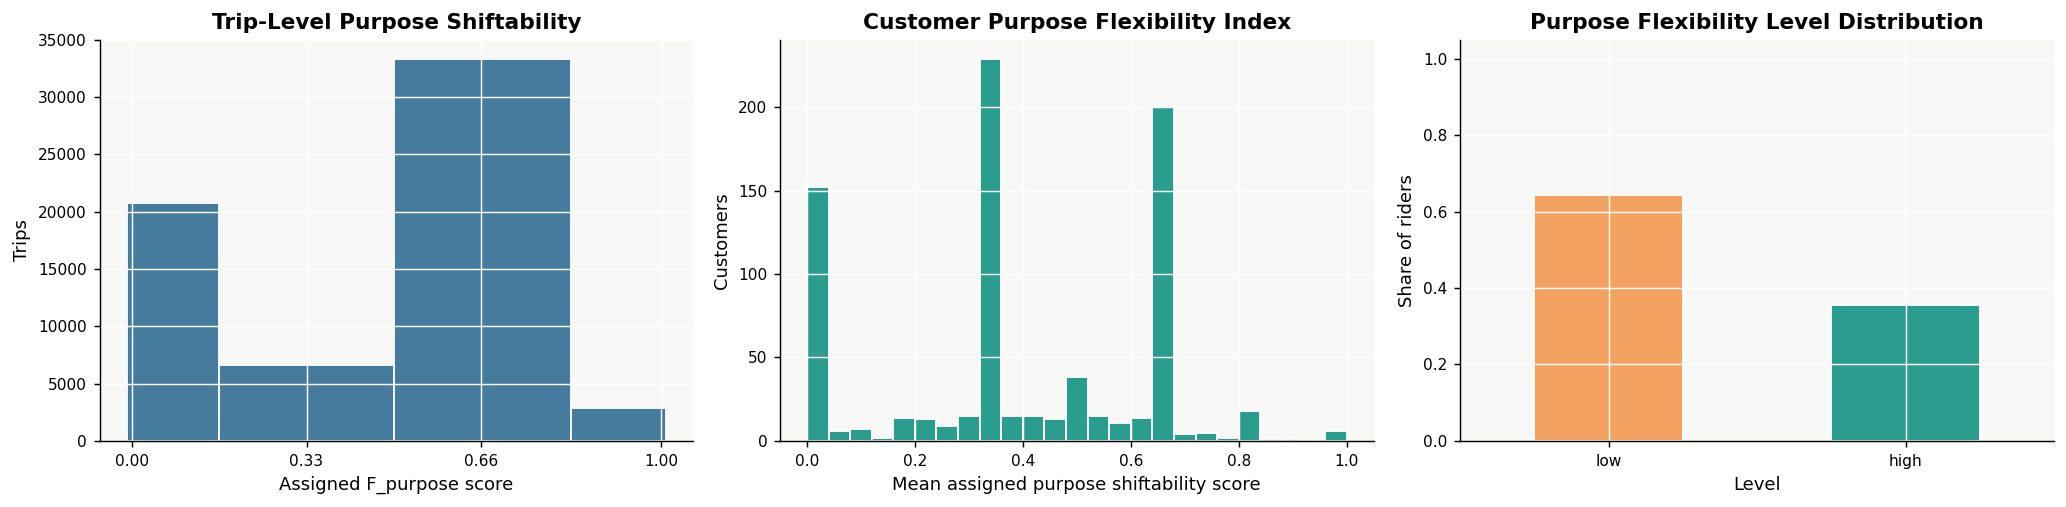

In [27]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
NEAREST_PURPOSE_POI_RADIUS_M = 250.0

poi_purpose = pd.read_csv(POI_PATH).dropna(subset=['lat']).copy()
POI_LON_COL = 'lon' if 'lon' in poi_purpose.columns else 'lng'
poi_purpose = poi_purpose.dropna(subset=[POI_LON_COL]).copy()

for source_col, target_col in [
    ('name', 'poi_name'),
    ('top_category', 'poi_top_category'),
    ('sub_category', 'poi_sub_category'),
    ('naics', 'poi_naics'),
]:
    if source_col in poi_purpose.columns:
        poi_purpose[target_col] = poi_purpose[source_col].fillna('').astype(str)
    else:
        poi_purpose[target_col] = ''


def haversine_matrix_m(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    return 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000


def purpose_level(value):
    if pd.isna(value):
        return np.nan
    if 0 <= value <= 0.5:
        return 'low'
    if 0.5 < value <= 1:
        return 'high'
    return np.nan


def clean_naics_prefix(naics, n_digits):
    text = '' if pd.isna(naics) else str(naics).strip().replace('.0', '')
    digits = ''.join(ch for ch in text if ch.isdigit())
    return digits[:n_digits]


def classify_purpose_shiftability(row):
    text = ' '.join([
        str(row.get('nearest_poi_name', '')),
        str(row.get('nearest_poi_top_category', '')),
        str(row.get('nearest_poi_sub_category', '')),
        str(row.get('recorded_purpose', '')),
    ]).lower()
    naics2 = clean_naics_prefix(row.get('nearest_poi_naics'), 2)
    naics3 = clean_naics_prefix(row.get('nearest_poi_naics'), 3)

    rigid_keywords = [
        'dialysis', 'renal', 'emergency', 'school', 'education', 'college',
        'universit', 'academy', 'employment', 'work', 'workshop', 'shift'
    ]
    if any(keyword in text for keyword in rigid_keywords) or naics2 == '61':
        return pd.Series({
            'purpose_shiftability_class': 'perfectly_rigid',
            'purpose_flexibility_score': 0.00,
        })

    high_keywords = [
        'grocery', 'supermarket', 'food market', 'restaurant', 'dining', 'cafe',
        'coffee', 'fast food', 'eating place', 'park', 'parks'
    ]
    if any(keyword in text for keyword in high_keywords) or naics3 in {'445', '722'}:
        return pd.Series({
            'purpose_shiftability_class': 'highly_flexible',
            'purpose_flexibility_score': 1.00,
        })

    low_keywords = [
        'medical', 'physician', 'doctor', 'clinic', 'health', 'hospital',
        'outpatient', 'dentist', 'pharmacy', 'pharmacies', 'drug store',
        'bank', 'credit', 'financial', 'government', 'courthouse', 'public administration',
        'official', 'social security', 'municipal', 'county', 'state office'
    ]
    if any(keyword in text for keyword in low_keywords) or naics2 in {'52', '62', '92'}:
        return pd.Series({
            'purpose_shiftability_class': 'low_flexibility',
            'purpose_flexibility_score': 0.33,
        })

    moderate_keywords = [
        'gym', 'fitness', 'recreation', 'amusement', 'family', 'relative',
        'visiting', 'retail', 'store', 'shopping', 'merchandise', 'department store',
        'salon', 'personal care', 'museum', 'library', 'community'
    ]
    if any(keyword in text for keyword in moderate_keywords) or naics2 in {'44', '45', '71'}:
        return pd.Series({
            'purpose_shiftability_class': 'moderate_flexibility',
            'purpose_flexibility_score': 0.66,
        })

    return pd.Series({
        'purpose_shiftability_class': 'moderate_flexibility',
        'purpose_flexibility_score': 0.66,
    })


purpose_trips = df_clean.copy()
purpose_trips['recorded_purpose'] = (
    purpose_trips['Purpose']
    .fillna('Unknown purpose')
    .astype(str)
    .str.strip()
    .replace('', 'Unknown purpose')
)

unique_purpose_destinations = (
    purpose_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'recorded_purpose']]
    .drop_duplicates()
    .reset_index(drop=True)
)

purpose_poi_distances_m = haversine_matrix_m(
    unique_purpose_destinations['dropoff_lat'],
    unique_purpose_destinations['dropoff_lon'],
    poi_purpose['lat'],
    poi_purpose[POI_LON_COL],
)
nearest_purpose_poi_idx = purpose_poi_distances_m.argmin(axis=1)
nearest_purpose_poi_distance_m = purpose_poi_distances_m[
    np.arange(len(unique_purpose_destinations)), nearest_purpose_poi_idx
]
nearest_purpose_pois = poi_purpose.iloc[nearest_purpose_poi_idx].reset_index(drop=True)
nearest_purpose_poi_matched = nearest_purpose_poi_distance_m <= NEAREST_PURPOSE_POI_RADIUS_M

unique_purpose_destinations['nearest_poi_name'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_name'].to_numpy(),
    np.nan,
)
unique_purpose_destinations['nearest_poi_top_category'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_top_category'].to_numpy(),
    np.nan,
)
unique_purpose_destinations['nearest_poi_sub_category'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_sub_category'].to_numpy(),
    np.nan,
)
unique_purpose_destinations['nearest_poi_naics'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_naics'].to_numpy(),
    np.nan,
)
unique_purpose_destinations['nearest_poi_distance_m'] = nearest_purpose_poi_distance_m
unique_purpose_destinations['used_poi_category_flag'] = nearest_purpose_poi_matched

purpose_shiftability = unique_purpose_destinations.apply(classify_purpose_shiftability, axis=1)
unique_purpose_destinations = pd.concat([unique_purpose_destinations, purpose_shiftability], axis=1)

purpose_trips = purpose_trips.merge(
    unique_purpose_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon', 'recorded_purpose',
        'nearest_poi_name', 'nearest_poi_top_category', 'nearest_poi_sub_category',
        'nearest_poi_naics', 'nearest_poi_distance_m', 'used_poi_category_flag',
        'purpose_shiftability_class', 'purpose_flexibility_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'recorded_purpose'],
    how='left',
)

customer_purpose_flexibility = (
    purpose_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        purpose_flexibility_index=('purpose_flexibility_score', 'mean'),
        median_purpose_flexibility_score=('purpose_flexibility_score', 'median'),
        rigid_purpose_trip_share=('purpose_flexibility_score', lambda s: (s == 0.00).mean()),
        low_purpose_trip_share=('purpose_flexibility_score', lambda s: (s == 0.33).mean()),
        moderate_purpose_trip_share=('purpose_flexibility_score', lambda s: (s == 0.66).mean()),
        high_purpose_trip_share=('purpose_flexibility_score', lambda s: (s == 1.00).mean()),
        poi_category_match_rate=('used_poi_category_flag', 'mean'),
        avg_nearest_poi_distance_m=('nearest_poi_distance_m', 'mean'),
        num_unique_recorded_purposes=('recorded_purpose', 'nunique'),
        num_unique_poi_categories=('nearest_poi_top_category', 'nunique'),
        dominant_shiftability_class=(
            'purpose_shiftability_class',
            lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan,
        ),
        dominant_recorded_purpose=(
            'recorded_purpose',
            lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan,
        ),
    )
    .reset_index()
)
customer_purpose_flexibility['purpose_flexibility_level'] = (
    customer_purpose_flexibility['purpose_flexibility_index'].apply(purpose_level)
)
customer_purpose_flexibility['purpose_profile'] = (
    'purpose_flexibility_index='
    + customer_purpose_flexibility['purpose_flexibility_level'].astype(str)
)
customer_purpose_flexibility['purpose_all_low_flag'] = (
    customer_purpose_flexibility['purpose_flexibility_level'].eq('low')
)
customer_purpose_flexibility['purpose_all_high_flag'] = (
    customer_purpose_flexibility['purpose_flexibility_level'].eq('high')
)

purpose_component_distribution = (
    customer_purpose_flexibility['purpose_flexibility_level']
    .value_counts(dropna=False)
    .rename_axis('level')
    .reset_index(name='customer_count')
    .assign(component='purpose_flexibility_index')
)
purpose_component_distribution['customer_share'] = (
    purpose_component_distribution['customer_count']
    / purpose_component_distribution['customer_count'].sum()
)
purpose_component_distribution = purpose_component_distribution[
    ['component', 'level', 'customer_count', 'customer_share']
].sort_values('level')

purpose_shiftability_distribution = (
    purpose_trips['purpose_shiftability_class']
    .value_counts(dropna=False)
    .rename_axis('purpose_shiftability_class')
    .reset_index(name='trip_count')
)
purpose_shiftability_distribution['trip_share'] = (
    purpose_shiftability_distribution['trip_count'] / len(purpose_trips)
)

purpose_group_summary = (
    customer_purpose_flexibility
    .groupby('purpose_flexibility_level', dropna=False)
    .agg(
        customer_count=('Customer Number', 'count'),
        mean_purpose_flexibility_index=('purpose_flexibility_index', 'mean'),
        mean_trip_frequency=('trip_frequency', 'mean'),
        mean_poi_category_match_rate=('poi_category_match_rate', 'mean'),
    )
    .reset_index()
    .sort_values('customer_count', ascending=False)
)
purpose_group_summary['customer_share'] = (
    purpose_group_summary['customer_count'] / len(customer_purpose_flexibility)
)

purpose_all_low_customers = customer_purpose_flexibility.loc[
    customer_purpose_flexibility['purpose_all_low_flag'],
    [
        'Customer Number', 'trip_frequency', 'purpose_flexibility_index',
        'rigid_purpose_trip_share', 'low_purpose_trip_share',
        'moderate_purpose_trip_share', 'high_purpose_trip_share',
        'dominant_shiftability_class', 'dominant_recorded_purpose',
    ]
].sort_values(['purpose_flexibility_index', 'trip_frequency'], ascending=[True, False])

purpose_all_high_customers = customer_purpose_flexibility.loc[
    customer_purpose_flexibility['purpose_all_high_flag'],
    [
        'Customer Number', 'trip_frequency', 'purpose_flexibility_index',
        'rigid_purpose_trip_share', 'low_purpose_trip_share',
        'moderate_purpose_trip_share', 'high_purpose_trip_share',
        'dominant_shiftability_class', 'dominant_recorded_purpose',
    ]
].sort_values(['purpose_flexibility_index', 'trip_frequency'], ascending=[False, False])

customer_purpose_flexibility = customer_purpose_flexibility.sort_values(
    ['purpose_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in purpose flexibility analysis: {len(customer_purpose_flexibility):,}")
print(
    f"Unique destination-purpose locations matched to nearby POIs: "
    f"{int(nearest_purpose_poi_matched.sum()):,} / {len(unique_purpose_destinations):,}"
)
print(f"Nearest POI category radius: {NEAREST_PURPOSE_POI_RADIUS_M:.0f} meters")
print(f"Customers in purpose all-low group: {int(customer_purpose_flexibility['purpose_all_low_flag'].sum()):,}")
print(f"Customers in purpose all-high group: {int(customer_purpose_flexibility['purpose_all_high_flag'].sum()):,}")

print('Trip-level purpose shiftability distribution:')
display(purpose_shiftability_distribution.style.format({
    'trip_count': '{:,.0f}',
    'trip_share': '{:.1%}',
}))

print('Top riders by purpose flexibility index:')
display(customer_purpose_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'purpose_flexibility_index': '{:.3f}',
    'median_purpose_flexibility_score': '{:.3f}',
    'rigid_purpose_trip_share': '{:.1%}',
    'low_purpose_trip_share': '{:.1%}',
    'moderate_purpose_trip_share': '{:.1%}',
    'high_purpose_trip_share': '{:.1%}',
    'poi_category_match_rate': '{:.1%}',
    'avg_nearest_poi_distance_m': '{:,.1f}',
    'num_unique_recorded_purposes': '{:,.0f}',
    'num_unique_poi_categories': '{:,.0f}',
}))
display(purpose_component_distribution.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
}))
display(purpose_group_summary.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
    'mean_purpose_flexibility_index': '{:.3f}',
    'mean_trip_frequency': '{:,.1f}',
    'mean_poi_category_match_rate': '{:.1%}',
}))
display(purpose_all_low_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'purpose_flexibility_index': '{:.3f}',
    'rigid_purpose_trip_share': '{:.1%}',
    'low_purpose_trip_share': '{:.1%}',
    'moderate_purpose_trip_share': '{:.1%}',
    'high_purpose_trip_share': '{:.1%}',
}))
display(purpose_all_high_customers.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'purpose_flexibility_index': '{:.3f}',
    'rigid_purpose_trip_share': '{:.1%}',
    'low_purpose_trip_share': '{:.1%}',
    'moderate_purpose_trip_share': '{:.1%}',
    'high_purpose_trip_share': '{:.1%}',
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    purpose_trips['purpose_flexibility_score'].dropna(),
    bins=[-0.01, 0.165, 0.495, 0.83, 1.01],
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Trip-Level Purpose Shiftability')
axes[0].set_xlabel('Assigned F_purpose score')
axes[0].set_ylabel('Trips')
axes[0].set_xticks([0.00, 0.33, 0.66, 1.00])

axes[1].hist(
    customer_purpose_flexibility['purpose_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[1].set_title('Customer Purpose Flexibility Index')
axes[1].set_xlabel('Mean assigned purpose shiftability score')
axes[1].set_ylabel('Customers')

purpose_level_plot = (
    purpose_component_distribution
    .set_index('level')['customer_share']
    .reindex(['low', 'high'])
    .fillna(0)
)
purpose_level_plot.plot(
    kind='bar',
    ax=axes[2],
    color=['#f4a261', '#2a9d8f'],
    edgecolor='white',
)
axes[2].set_title('Purpose Flexibility Level Distribution')
axes[2].set_xlabel('Level')
axes[2].set_ylabel('Share of riders')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [28]:
def minmax_normalize_series(s):
    s = s.astype(float)
    valid = s.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=s.index)
    min_value = valid.min()
    max_value = valid.max()
    if np.isclose(max_value, min_value):
        return pd.Series(0.0, index=s.index)
    return (s - min_value) / (max_value - min_value)


def low_high_level(value):
    if pd.isna(value):
        return np.nan
    if 0 <= value <= 0.5:
        return 'low'
    if 0.5 < value <= 1:
        return 'high'
    return np.nan


def safe_spearman(group, x_col, y_col):
    valid = group[[x_col, y_col]].dropna()
    if len(valid) < 3:
        return np.nan
    if valid[x_col].nunique() <= 1 or valid[y_col].nunique() <= 1:
        return np.nan
    return valid[x_col].corr(valid[y_col], method='spearman')


trip_status_customer = df_raw['Trip Status'].astype('string').str.strip().str.lower()
cancel_statuses_customer = ['cancel', 'canceled', 'cancelled']
completed_statuses_customer = ['comp', 'completed']
noshow_statuses_customer = ['noshow', 'no show', 'no-show']

customer_trip_outcomes = (
    df_raw.assign(status_clean=trip_status_customer)
    .groupby('Customer Number')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(completed_statuses_customer).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(cancel_statuses_customer).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(noshow_statuses_customer).sum()),
    )
    .reset_index()
)
customer_trip_outcomes['completion_rate'] = (
    customer_trip_outcomes['completed_trips'] / customer_trip_outcomes['total_trips']
)
customer_trip_outcomes['cancellation_rate'] = (
    customer_trip_outcomes['cancelled_trips'] / customer_trip_outcomes['total_trips']
)
customer_trip_outcomes['noshow_rate'] = (
    customer_trip_outcomes['noshow_trips'] / customer_trip_outcomes['total_trips']
)
customer_trip_outcomes['has_any_cancellation'] = customer_trip_outcomes['cancelled_trips'] > 0

customer_cancel_reasons = (
    df_raw.assign(
        status_clean=trip_status_customer,
        cancel_type_clean=(
            df_raw['Cancel Type']
            .fillna('Missing / Unknown')
            .astype(str)
            .str.strip()
            .replace('', 'Missing / Unknown')
        ),
    )
)
customer_cancel_reasons = customer_cancel_reasons.loc[
    customer_cancel_reasons['status_clean'].isin(cancel_statuses_customer),
    ['Customer Number', 'Trip ID', 'cancel_type_clean']
]

customer_three_dimensional_flexibility = (
    customer_temporal_deviation_tolerance[[
        'Customer Number', 'temporal_deviation_tolerance'
    ]]
    .merge(
        customer_geographical_flexibility[[
            'Customer Number', 'geographical_flexibility_index'
        ]],
        on='Customer Number',
        how='inner',
    )
    .merge(
        customer_purpose_flexibility[[
            'Customer Number', 'purpose_flexibility_index'
        ]],
        on='Customer Number',
        how='inner',
    )
)

customer_three_dimensional_flexibility['temporal_deviation_tolerance_score_norm'] = minmax_normalize_series(
    customer_three_dimensional_flexibility['temporal_deviation_tolerance']
)
customer_three_dimensional_flexibility['temporal_deviation_tolerance_level'] = (
    customer_three_dimensional_flexibility['temporal_deviation_tolerance_score_norm'].apply(low_high_level)
)
customer_three_dimensional_flexibility['geographical_flexibility_level'] = (
    customer_three_dimensional_flexibility['geographical_flexibility_index'].apply(low_high_level)
)
customer_three_dimensional_flexibility['purpose_flexibility_level'] = (
    customer_three_dimensional_flexibility['purpose_flexibility_index'].apply(low_high_level)
)
customer_three_dimensional_flexibility['flexibility_group_8'] = (
    'temporal_deviation_tolerance=' + customer_three_dimensional_flexibility['temporal_deviation_tolerance_level'].astype(str)
    + ', geographical=' + customer_three_dimensional_flexibility['geographical_flexibility_level'].astype(str)
    + ', purpose=' + customer_three_dimensional_flexibility['purpose_flexibility_level'].astype(str)
)

customer_three_dimensional_flexibility = customer_three_dimensional_flexibility.merge(
    customer_trip_outcomes,
    on='Customer Number',
    how='left',
)

flexibility_group_relationship_summary = (
    customer_three_dimensional_flexibility
    .groupby(
        [
            'temporal_deviation_tolerance_level',
            'geographical_flexibility_level',
            'purpose_flexibility_level',
            'flexibility_group_8',
        ],
        dropna=False,
    )
    .agg(
        customer_count=('Customer Number', 'count'),
        mean_temporal_deviation_tolerance=('temporal_deviation_tolerance_score_norm', 'mean'),
        mean_geographical_flexibility=('geographical_flexibility_index', 'mean'),
        mean_purpose_flexibility=('purpose_flexibility_index', 'mean'),
        mean_total_trips=('total_trips', 'mean'),
        mean_completion_rate=('completion_rate', 'mean'),
        median_completion_rate=('completion_rate', 'median'),
        mean_cancellation_rate=('cancellation_rate', 'mean'),
        median_cancellation_rate=('cancellation_rate', 'median'),
        mean_noshow_rate=('noshow_rate', 'mean'),
        customers_with_any_cancellation=('has_any_cancellation', 'sum'),
    )
    .reset_index()
    .sort_values(
        ['temporal_deviation_tolerance_level', 'geographical_flexibility_level', 'purpose_flexibility_level']
    )
)
flexibility_group_relationship_summary['customer_share'] = (
    flexibility_group_relationship_summary['customer_count']
    / len(customer_three_dimensional_flexibility)
)
flexibility_group_relationship_summary['share_with_any_cancellation'] = (
    flexibility_group_relationship_summary['customers_with_any_cancellation']
    / flexibility_group_relationship_summary['customer_count']
)

flexibility_group_correlations = (
    customer_three_dimensional_flexibility
    .groupby(
        [
            'temporal_deviation_tolerance_level',
            'geographical_flexibility_level',
            'purpose_flexibility_level',
            'flexibility_group_8',
        ],
        dropna=False,
    )
    .apply(
        lambda g: pd.Series({
            'temporal_deviation_tolerance_vs_completion_spearman': safe_spearman(g, 'temporal_deviation_tolerance_score_norm', 'completion_rate'),
            'temporal_deviation_tolerance_vs_cancellation_spearman': safe_spearman(g, 'temporal_deviation_tolerance_score_norm', 'cancellation_rate'),
            'geographical_vs_completion_spearman': safe_spearman(g, 'geographical_flexibility_index', 'completion_rate'),
            'geographical_vs_cancellation_spearman': safe_spearman(g, 'geographical_flexibility_index', 'cancellation_rate'),
            'purpose_vs_completion_spearman': safe_spearman(g, 'purpose_flexibility_index', 'completion_rate'),
            'purpose_vs_cancellation_spearman': safe_spearman(g, 'purpose_flexibility_index', 'cancellation_rate'),
        })
    )
    .reset_index()
)

flexibility_group_relationship_summary = flexibility_group_relationship_summary.merge(
    flexibility_group_correlations,
    on=[
        'temporal_deviation_tolerance_level',
        'geographical_flexibility_level',
        'purpose_flexibility_level',
        'flexibility_group_8',
    ],
    how='left',
)

group_cancel_reason_summary = customer_cancel_reasons.merge(
    customer_three_dimensional_flexibility[[
        'Customer Number',
        'temporal_deviation_tolerance_level',
        'geographical_flexibility_level',
        'purpose_flexibility_level',
        'flexibility_group_8',
    ]],
    on='Customer Number',
    how='inner',
)
group_cancel_reason_summary = (
    group_cancel_reason_summary
    .groupby(
        [
            'temporal_deviation_tolerance_level',
            'geographical_flexibility_level',
            'purpose_flexibility_level',
            'flexibility_group_8',
            'cancel_type_clean',
        ],
        dropna=False,
    )
    .agg(num_cancellations=('Trip ID', 'count'))
    .reset_index()
)
group_cancel_reason_summary['group_total_cancellations'] = (
    group_cancel_reason_summary.groupby('flexibility_group_8')['num_cancellations'].transform('sum')
)
group_cancel_reason_summary['share_of_group_cancellations'] = (
    group_cancel_reason_summary['num_cancellations']
    / group_cancel_reason_summary['group_total_cancellations']
)
group_cancel_reason_summary = group_cancel_reason_summary.sort_values(
    ['flexibility_group_8', 'num_cancellations'],
    ascending=[True, False],
)

top_cancel_reason_by_group = (
    group_cancel_reason_summary
    .groupby('flexibility_group_8', as_index=False)
    .first()
    .rename(columns={'cancel_type_clean': 'top_cancel_type'})
)

print('8-group customer segmentation across temporal, geographical, and purpose flexibility:')
display(flexibility_group_relationship_summary.style.format({
    'customer_count': '{:,.0f}',
    'customer_share': '{:.1%}',
    'mean_temporal_deviation_tolerance': '{:.3f}',
    'mean_geographical_flexibility': '{:.3f}',
    'mean_purpose_flexibility': '{:.3f}',
    'mean_total_trips': '{:,.1f}',
    'mean_completion_rate': '{:.2%}',
    'median_completion_rate': '{:.2%}',
    'mean_cancellation_rate': '{:.2%}',
    'median_cancellation_rate': '{:.2%}',
    'mean_noshow_rate': '{:.2%}',
    'customers_with_any_cancellation': '{:,.0f}',
    'share_with_any_cancellation': '{:.2%}',
    'temporal_deviation_tolerance_vs_completion_spearman': '{:.3f}',
    'temporal_deviation_tolerance_vs_cancellation_spearman': '{:.3f}',
    'geographical_vs_completion_spearman': '{:.3f}',
    'geographical_vs_cancellation_spearman': '{:.3f}',
    'purpose_vs_completion_spearman': '{:.3f}',
    'purpose_vs_cancellation_spearman': '{:.3f}',
}))

print('Top cancellation reason within each 8-group:')
display(top_cancel_reason_by_group.style.format({
    'num_cancellations': '{:,.0f}',
    'group_total_cancellations': '{:,.0f}',
    'share_of_group_cancellations': '{:.2%}',
}))

print('Detailed cancellation-reason mix for each 8-group:')
display(group_cancel_reason_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'group_total_cancellations': '{:,.0f}',
    'share_of_group_cancellations': '{:.2%}',
}))


8-group customer segmentation across temporal, geographical, and purpose flexibility:


,temporal_deviation_tolerance_level,geographical_flexibility_level,purpose_flexibility_level,flexibility_group_8,customer_count,mean_temporal_deviation_tolerance,mean_geographical_flexibility,mean_purpose_flexibility,mean_total_trips,mean_completion_rate,median_completion_rate,mean_cancellation_rate,median_cancellation_rate,mean_noshow_rate,customers_with_any_cancellation,customer_share,share_with_any_cancellation,temporal_deviation_tolerance_vs_completion_spearman,temporal_deviation_tolerance_vs_cancellation_spearman,geographical_vs_completion_spearman,geographical_vs_cancellation_spearman,purpose_vs_completion_spearman,purpose_vs_cancellation_spearman
0,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",23,0.712,0.743,0.729,278.5,44.66%,45.83%,51.12%,54.02%,4.22%,23,2.9%,100.00%,0.356,-0.430,-0.210,0.118,0.154,-0.167
1,high,high,low,"temporal_deviation_tolerance=high, geographical=high, purpose=low",4,0.753,0.758,0.301,333.0,45.45%,52.65%,46.37%,47.18%,8.18%,4,0.5%,100.00%,-0.400,0.400,-0.600,0.600,0.600,-0.600
2,high,low,high,"temporal_deviation_tolerance=high, geographical=low, purpose=high",82,0.725,0.109,0.669,180.2,42.78%,42.74%,53.52%,51.87%,3.70%,82,10.2%,100.00%,-0.174,0.146,0.405,-0.465,0.455,-0.506
3,high,low,low,"temporal_deviation_tolerance=high, geographical=low, purpose=low",330,0.733,0.017,0.215,136.6,44.66%,43.40%,52.75%,53.33%,2.59%,325,40.9%,98.48%,-0.099,0.089,0.023,-0.026,-0.436,0.438
4,high,nan,high,"temporal_deviation_tolerance=high, geographical=nan, purpose=high",77,0.761,nan,0.660,292.0,47.55%,47.31%,48.62%,49.19%,3.83%,76,9.6%,98.70%,-0.071,0.080,nan,nan,-0.098,0.095
5,high,nan,low,"temporal_deviation_tolerance=high, geographical=nan, purpose=low",4,0.932,nan,0.000,101.0,57.24%,58.08%,42.29%,41.00%,0.46%,4,0.5%,100.00%,0.738,-0.738,nan,nan,nan,nan
6,low,high,high,"temporal_deviation_tolerance=low, geographical=high, purpose=high",11,0.400,0.742,0.683,171.7,51.75%,46.88%,43.91%,41.67%,4.34%,11,1.4%,100.00%,0.278,-0.036,-0.509,0.300,-0.526,0.579
7,low,high,low,"temporal_deviation_tolerance=low, geographical=high, purpose=low",4,0.447,0.792,0.206,157.2,49.47%,47.32%,49.62%,52.68%,0.91%,4,0.5%,100.00%,-0.400,0.400,0.400,-0.400,-0.316,0.316
8,low,low,high,"temporal_deviation_tolerance=low, geographical=low, purpose=high",33,0.353,0.030,0.636,66.7,40.32%,35.29%,57.40%,60.00%,2.28%,30,4.1%,90.91%,-0.044,0.081,0.097,-0.099,0.181,-0.214
9,low,low,low,"temporal_deviation_tolerance=low, geographical=low, purpose=low",176,0.296,0.005,0.276,58.5,40.98%,38.46%,54.71%,58.58%,4.31%,168,21.8%,95.45%,0.144,-0.083,0.034,-0.146,-0.087,0.072


Top cancellation reason within each 8-group:


,flexibility_group_8,temporal_deviation_tolerance_level,geographical_flexibility_level,purpose_flexibility_level,top_cancel_type,num_cancellations,group_total_cancellations,share_of_group_cancellations
0,"temporal_deviation_tolerance=high, geographical=high, purpose=high",high,high,high,Advanced Cancel,"1,172","2,926",40.05%
1,"temporal_deviation_tolerance=high, geographical=high, purpose=low",high,high,low,Renegotiation,190,546,34.80%
2,"temporal_deviation_tolerance=high, geographical=low, purpose=high",high,low,high,Trip correction,"2,167","6,753",32.09%
3,"temporal_deviation_tolerance=high, geographical=low, purpose=low",high,low,low,Trip correction,"9,675","21,143",45.76%
4,"temporal_deviation_tolerance=high, geographical=nan, purpose=high",high,None,high,Advanced Cancel,"3,927","9,755",40.26%
5,"temporal_deviation_tolerance=high, geographical=nan, purpose=low",high,None,low,Modified,59,152,38.82%
6,"temporal_deviation_tolerance=low, geographical=high, purpose=high",low,high,high,Advanced Cancel,329,748,43.98%
7,"temporal_deviation_tolerance=low, geographical=high, purpose=low",low,high,low,Advanced Cancel,88,246,35.77%
8,"temporal_deviation_tolerance=low, geographical=low, purpose=high",low,low,high,Advanced Cancel,542,"1,206",44.94%
9,"temporal_deviation_tolerance=low, geographical=low, purpose=low",low,low,low,Trip correction,"1,687","4,554",37.04%


Detailed cancellation-reason mix for each 8-group:


,temporal_deviation_tolerance_level,geographical_flexibility_level,purpose_flexibility_level,flexibility_group_8,cancel_type_clean,num_cancellations,group_total_cancellations,share_of_group_cancellations
0,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Advanced Cancel,"1,172","2,926",40.05%
7,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Renegotiation,596,"2,926",20.37%
8,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Site closure,395,"2,926",13.50%
9,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Trip correction,333,"2,926",11.38%
4,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Modified,281,"2,926",9.60%
10,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",User Error Cancel,78,"2,926",2.67%
2,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Late Cancel,46,"2,926",1.57%
1,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Denial,16,"2,926",0.55%
3,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Missing / Unknown,4,"2,926",0.14%
5,high,high,high,"temporal_deviation_tolerance=high, geographical=high, purpose=high",Policy Cancel,2,"2,926",0.07%


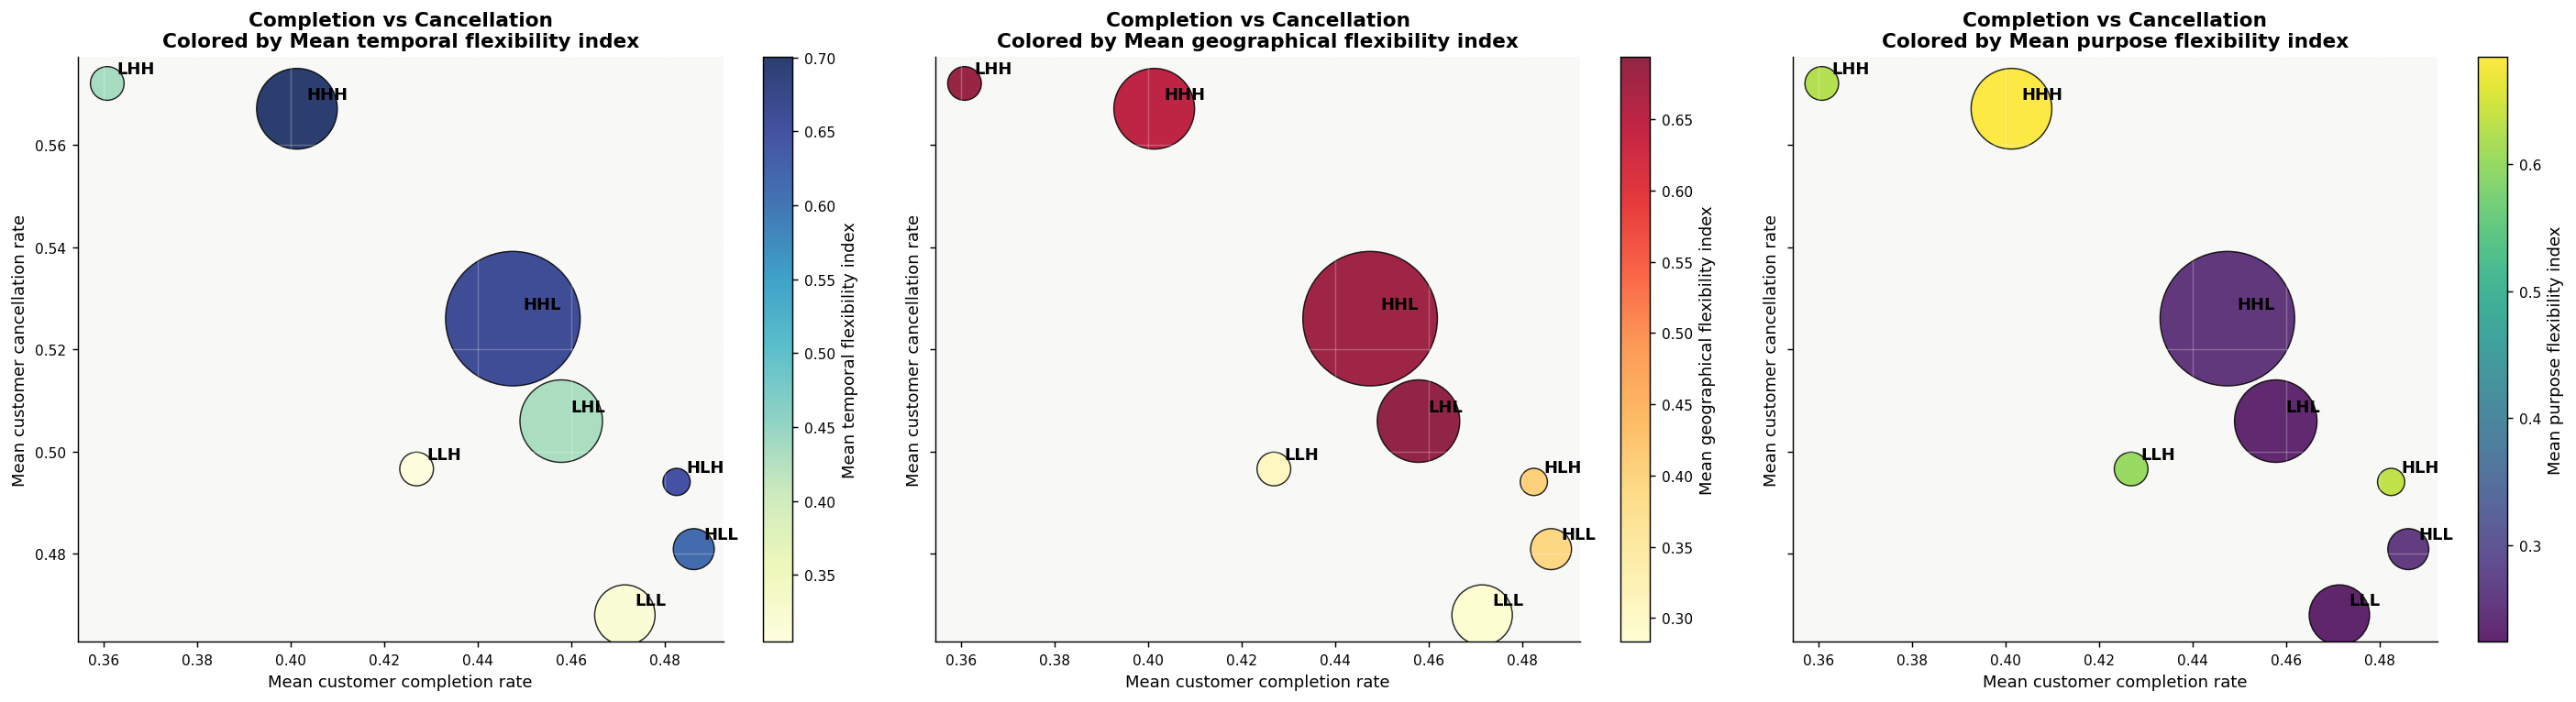

Group label key: T/G/P = Temporal, Geographical, Purpose flexibility; H = high, L = low.


,group_code,temporal_flexibility_level,geographical_flexibility_level,purpose_flexibility_level,customer_count,mean_completion_rate,mean_cancellation_rate
0,HHH,high,high,high,132,0.401279,0.567087
1,HHL,high,high,low,367,0.447433,0.526004
2,HLH,high,low,high,15,0.482433,0.494048
3,HLL,high,low,low,34,0.486107,0.480894
4,LHH,low,high,high,23,0.360730,0.572042
5,LHL,low,high,low,138,0.457772,0.505949
6,LLH,low,low,high,23,0.426857,0.496580
7,LLL,low,low,low,74,0.471377,0.467988


In [ ]:
group_plot_data = flexibility_group_relationship_summary.copy()
group_plot_data = group_plot_data.dropna(subset=['mean_completion_rate', 'mean_cancellation_rate'])

group_plot_data['group_code'] = (
    group_plot_data['temporal_deviation_tolerance_level'].str[0].str.upper()
    + group_plot_data['geographical_flexibility_level'].str[0].str.upper()
    + group_plot_data['purpose_flexibility_level'].str[0].str.upper()
)

plot_specs = [
    ('mean_temporal_deviation_tolerance', 'Mean temporal deviation tolerance', 'YlGnBu'),
    ('mean_geographical_flexibility', 'Mean geographical flexibility index', 'YlOrRd'),
    ('mean_purpose_flexibility', 'Mean purpose flexibility index', 'viridis'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True, sharey=True)

for ax, (color_col, color_label, cmap) in zip(axes, plot_specs):
    scatter = ax.scatter(
        group_plot_data['mean_completion_rate'],
        group_plot_data['mean_cancellation_rate'],
        s=group_plot_data['customer_count'].fillna(0) * 18,
        c=group_plot_data[color_col],
        cmap=cmap,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.8,
    )

    for _, row in group_plot_data.iterrows():
        ax.annotate(
            row['group_code'],
            (row['mean_completion_rate'], row['mean_cancellation_rate']),
            textcoords='offset points',
            xytext=(6, 6),
            fontsize=10,
            fontweight='bold',
        )

    ax.set_title(f'Completion vs Cancellation\nColored by {color_label}')
    ax.set_xlabel('Mean customer completion rate')
    ax.set_ylabel('Mean customer cancellation rate')
    ax.grid(alpha=0.25)

    colorbar = plt.colorbar(scatter, ax=ax)
    colorbar.set_label(color_label)

plt.tight_layout()
plt.show()

print('Group label key: T/G/P = Temporal deviation tolerance, Geographical flexibility, Purpose flexibility; H = high, L = low.')
display(
    group_plot_data[
        [
            'group_code',
            'temporal_deviation_tolerance_level',
            'geographical_flexibility_level',
            'purpose_flexibility_level',
            'customer_count',
            'mean_completion_rate',
            'mean_cancellation_rate',
        ]
    ].sort_values('group_code').reset_index(drop=True)
)


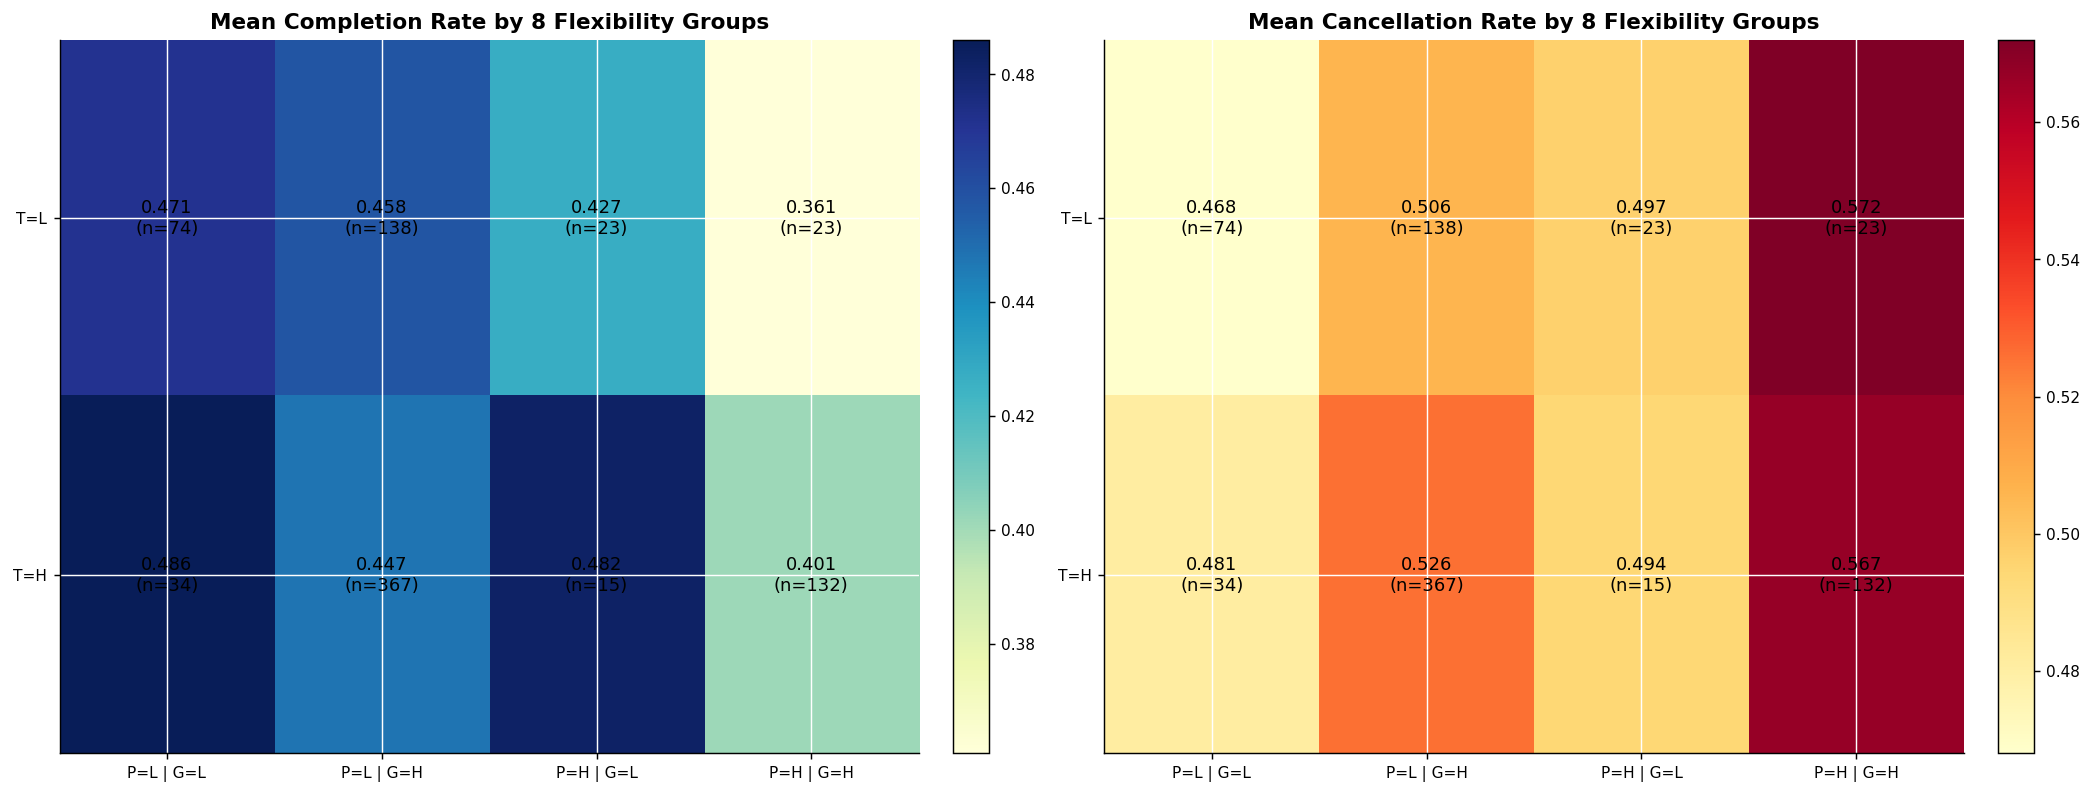

Heatmap axis key: T = Temporal flexibility, P = Purpose flexibility, G = Geographical flexibility.


In [ ]:
heatmap_source = flexibility_group_relationship_summary.copy()
heatmap_source = heatmap_source.assign(
    temporal_deviation_tolerance_level=pd.Categorical(
        heatmap_source['temporal_deviation_tolerance_level'], categories=['low', 'high'], ordered=True
    ),
    geographical_flexibility_level=pd.Categorical(
        heatmap_source['geographical_flexibility_level'], categories=['low', 'high'], ordered=True
    ),
    purpose_flexibility_level=pd.Categorical(
        heatmap_source['purpose_flexibility_level'], categories=['low', 'high'], ordered=True
    ),
)

column_order = [('low', 'low'), ('low', 'high'), ('high', 'low'), ('high', 'high')]

heatmap_completion = heatmap_source.pivot_table(
    index='temporal_deviation_tolerance_level',
    columns=['purpose_flexibility_level', 'geographical_flexibility_level'],
    values='mean_completion_rate',
    aggfunc='mean',
).reindex(index=['low', 'high'])
heatmap_completion = heatmap_completion.reindex(columns=pd.MultiIndex.from_tuples(column_order))

heatmap_cancellation = heatmap_source.pivot_table(
    index='temporal_deviation_tolerance_level',
    columns=['purpose_flexibility_level', 'geographical_flexibility_level'],
    values='mean_cancellation_rate',
    aggfunc='mean',
).reindex(index=['low', 'high'])
heatmap_cancellation = heatmap_cancellation.reindex(columns=pd.MultiIndex.from_tuples(column_order))

heatmap_count = heatmap_source.pivot_table(
    index='temporal_deviation_tolerance_level',
    columns=['purpose_flexibility_level', 'geographical_flexibility_level'],
    values='customer_count',
    aggfunc='sum',
).reindex(index=['low', 'high'])
heatmap_count = heatmap_count.reindex(columns=pd.MultiIndex.from_tuples(column_order))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

plot_specs = [
    (axes[0], heatmap_completion, 'YlGnBu', 'Mean Completion Rate by 8 Flexibility Groups'),
    (axes[1], heatmap_cancellation, 'YlOrRd', 'Mean Cancellation Rate by 8 Flexibility Groups'),
]

x_labels = ['P=L | G=L', 'P=L | G=H', 'P=H | G=L', 'P=H | G=H']
y_labels = ['T=L', 'T=H']

for ax, matrix, cmap, title in plot_specs:
    values = matrix.to_numpy(dtype=float)
    image = ax.imshow(values, cmap=cmap, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels)

    for row_idx in range(values.shape[0]):
        for col_idx in range(values.shape[1]):
            value = values[row_idx, col_idx]
            count_value = heatmap_count.to_numpy(dtype=float)[row_idx, col_idx]
            if np.isnan(value):
                text = 'NA'
            else:
                if np.isnan(count_value):
                    text = f'{value:.3f}'
                else:
                    text = f'{value:.3f}\n(n={int(count_value)})'
            ax.text(col_idx, row_idx, text, ha='center', va='center', color='black', fontsize=10)

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.show()

print('Heatmap axis key: T = Temporal deviation tolerance, P = Purpose flexibility, G = Geographical flexibility.')


# 4. Add the Alabama block group shapefile, filters to Jefferson County CBG polygons 

In [ ]:
import geopandas as gpd

BG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp")

# Load Jefferson County block group polygons and attach the CBG attributes.
cbg_poly = gpd.read_file(BG_PATH)
cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

df_cbg = df_cbg.copy()
df_cbg['GEOID'] = (
    df_cbg['state'].astype(int).astype(str).str.zfill(2)
    + df_cbg['county'].astype(int).astype(str).str.zfill(3)
    + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
    + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
)
cbg_poly = cbg_poly.merge(df_cbg, on='GEOID', how='left')

# Spatially mark each trip's pickup and dropoff block group.
pickup_points = gpd.GeoDataFrame(
    df_clean[['pickup_lon', 'pickup_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
pickup_points['trip_index'] = df_clean.index

dropoff_points = gpd.GeoDataFrame(
    df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
dropoff_points['trip_index'] = df_clean.index

pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')

pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

pickup_blocks = set(df_clean['pickup_bg_geoid'].dropna())
dropoff_blocks = set(df_clean['dropoff_bg_geoid'].dropna())

pickup_counts = df_clean['pickup_bg_geoid'].value_counts()
dropoff_counts = df_clean['dropoff_bg_geoid'].value_counts()
cbg_poly['pickup_trip_count'] = cbg_poly['GEOID'].map(pickup_counts).fillna(0).astype(int)
cbg_poly['dropoff_trip_count'] = cbg_poly['GEOID'].map(dropoff_counts).fillna(0).astype(int)

print(f"Pickup points mapped to CBGs: {df_clean['pickup_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Dropoff points mapped to CBGs: {df_clean['dropoff_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Pickup blocks: {len(pickup_blocks):,}; dropoff blocks: {len(dropoff_blocks):,}; overlap: {len(pickup_blocks & dropoff_blocks):,}")

from matplotlib.colors import PowerNorm

vmax = max(cbg_poly['pickup_trip_count'].max(), cbg_poly['dropoff_trip_count'].max())
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
pickup_plot = pickup_points.sample(min(1500, len(pickup_points)), random_state=42)
dropoff_plot = dropoff_points.sample(min(1500, len(dropoff_points)), random_state=42)

minx, miny, maxx, maxy = pickup_points.total_bounds
dx = (maxx - minx) * 0.08
dy = (maxy - miny) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

cbg_poly.plot(
    ax=axes[0], column='pickup_trip_count', cmap='Blues', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed pickup trips per CBG', 'shrink': 0.72},
)
pickup_plot.plot(ax=axes[0], markersize=2.0, color='black', alpha=0.22)
axes[0].set_title('Pickup Demand by Census Block Group')

cbg_poly.plot(
    ax=axes[1], column='dropoff_trip_count', cmap='Oranges', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed dropoff trips per CBG', 'shrink': 0.72},
)
dropoff_plot.plot(ax=axes[1], markersize=2.0, color='black', alpha=0.22)
axes[1].set_title('Dropoff Demand by Census Block Group')

for ax in axes:
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_axis_off()

fig.suptitle('Completed Trip Pickup and Dropoff Demand in Jefferson County CBGs', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()


RFI = w1 * temporal_deviation_tolerance
    + w2 * purpose_flexibility
    + w3 * geographical_flexibility
    - w4 * regularity_penalty